In [1]:
%load_ext autoreload
%autoreload 2

<a id="main"></a>
-------
# **Bacterial Community Model Simulator**
-------
*Raffaele Gaudio 2057974*, *Marco Lorenzetti 2056112*

<br/>

*A fundamental goal of microbial ecology is to understand what determines the diversity, stability, and structure of microbial ecosystems. 
The main aim of this project is to re-implement the model proposed by Robert Marsland III et al. to describe a microbial community that explicitly takes into account cross-feeding and stochastic colonization. 
We will also explore how this model presents a transition as a function of available energy fluxes from a *Resource Limited* regime where community structure and stability is shaped by energetic and metabolic considerations to a *Diverse Regime* where the dominant force shaping microbial communities is the overlap between species' consumption preferences. In addition, we will investigate how the presence of multiple energy sources external to the community impacts on the average richness of the community and the behavior of the system for high leakage values in presence of a single external resource.*

<a id="main"></a>

## Contents
- 1. [Overview of the model](#1)

- 2. [Implementation details](#2)
        - 2.1. [Response function](#21)
        - 2.2. [Consumer preference matrix](#22)
             - 2.2.1. [Gaussian sampling](#221)
             - 2.2.2. [Binary sampling](#222)
        - 2.3. [Externally supplied resource function](#23)
        - 2.4. [Metabolic matrix](#24)      
- 3. [Structure of the $\texttt{CommunityModelClass.py}$](#3)
- 4. [Class demo](#4)
        - 4.1 [Diverse regime](#41)
        - 4.2 [Restricted regime](#42)
- 5. [Simulations](#5)
        - 5.1. [Stability time](#51)
        - 5.2. [Mean Richness and mean Simpson Diversity](#52)
        - 5.3. [Niche Overlap](#53)
        - 5.4. [Mean Richness whit multiple external resources](#54)
             - 5.4.1. [Two external resources](#541)
             - 5.4.2. [Three external resources](#542)
             - 5.4.3. [Four external resources](#543)
             - 5.4.4 [Multiple external resources comparison](#554)
        - 5.5. [High leakage behavior with a single external resource](#55)
- 6. [Conclusions and future works](#6)
-   [Bibliography](#bibliography)

<a id="1"></a>
<a href ="#main"><p style="text-align: right;">return to contents</p></a>
## 1. Overview of the model

<center>
<img src="model.png" alt="Drawing" style="width: 400px;"/>
<center>



The starting point of our implementation is a model that adapts MacArtur's Consumer Resource Model [1] in the microbial context by including energetics, stochastic colonization and the exchange and consumption of metabolite. This model was presented by Robert Marsland III et al. in PLoS computational biology 15.2 (2019) [2].

We consider the population dynamics of S species of consumers (e.g., microbes) competing for M types of substitutable resources. In the model, the rate at which an individual of species $i$ harvests energy from resource $\alpha$ (incoming flux) depends on the resource concentration $R_\alpha$ as well as on the consumer’s vector of resource preferences $c_{i\alpha}$:

$$
J_{i\alpha}^{\text{in}}=w_\alpha \sigma(c_{i\alpha}R_\alpha)
$$

where $\sigma(x)$ encodes the functional response and has units of mass/time, while $w_\alpha$ is the energy density of resource $\alpha$ with units of energy/mass.

The leakage and secretion are modeled by letting a fraction $l_\alpha$ of this imported energy return to the environment, so that the power available to the cell for sustaining growth is equal to:

$$
J_i^{\text{growth}}=\sum_\alpha (1-l_\alpha)J_{i\alpha}^{in}
$$

It is assumed that a fixed quantity $m_i$ of power per cell is required for maintenance of species $i$, and that the per-capita growth rate is proportional to the remaining energy flux, with proportionality constant $g_i$. Under these assumptions, the time-evolution of the population size $N_i$ of species $i$ is:

$$
\frac{dN_i}{dt} = g_i N_i \left[J_i^{\text{growth}}-m_i\right] 
$$

The leaked energy flux from each cell of species $i$ is partitioned among the M possible resource types via the biochemical pathways operating within the cell and is defined as:

$$
J_i^{\text{out}}=\sum_\alpha l_\alpha J_{i\alpha}^{\text{in}}
$$

The model assumes that all species share a similar core metabolism, encoded in a matrix $D_{\alpha\beta}$. Each element of this matrix specifies the fraction of leaked energy from resource $\alpha$ that is released in the form of resource $\beta$. Thus, the resources that are excreted into the environment are coupled to the resources a cell is consuming. The outgoing energy flux contained in metabolite $\beta$ is given by:

$$
J_{i\beta}^{\text{out}}=w_\beta \nu_{i\beta}^{\text{out}}= \sum_\alpha D_{\alpha\beta} l_\alpha J_\alpha^{\text{in}}
$$

The dynamics of the resource concentrations depend on the incoming and outgoing mass fluxes $\nu_{i\alpha}^{\text{in}} = \sigma(c_{i\alpha}R_\alpha)$ and $\nu_{i\alpha}^{\text{out}}$ which are related to the energy fluxes via the energy densities $w_\alpha$. In terms of these quantities, the resources dynamics is:

$$
\frac{dR_\alpha}{dt}  = h_\alpha-\sum_j N_j(\nu_{i\alpha}^{\text{out}}-\nu_{i\alpha}^{\text{in}})
$$

with $h_\alpha$ encoding the dynamics of externally supplied resources.

<a id="2"></a>
<a href ="#main"><p style="text-align: right;">return to contents</p></a>
## 2. Implemetation details

To try to capture metabolic structure, the $M$ resources are partitioned into $T$ classes (e.g. sugars, amino acids, etc.), each with $M_A$ resources where $A = 1,...,T$ and $\sum_A M_A = M$. In a similar way, the consumers are partitioned into $F$ families and each one has a preference for one resource class $A$.


The explicit form of the dynamics of the model is:

$$
\begin{split}
& \frac{dN_i}{dt} = g_i N_i \left[\sum_\alpha (1-l_\alpha)w_\alpha \sigma(c_{i\alpha}R_\alpha)-m_i\right] \\
& \frac{dR_\alpha}{dt}  = h_\alpha(R_\alpha)-\sum_j N_j \sigma(c_{j\alpha}R_\alpha) + \sum_{j\beta} N_j \sigma(c_{j\beta}R_\beta)\left[D_{\alpha\beta}\frac{w_\beta}{w_\alpha}l_\beta\right]
\end{split}
$$

in which we can identify:
- $\sigma(x)$: the response function
- $c_{i\alpha}$: the consumer preference matrix
- $h_\alpha(R_\alpha)$: the externally supplied resources function
- $D_{\alpha\beta}$: the metabolic matrix

<a id="21"></a>
### 2.1 Response function 

The function $\sigma(x)$ encodes the response of consumer $i$ for resource $\alpha$. In our implementation of the model, two kinds of response function are considered: linear and monod.

$$
\sigma(x) \equiv \begin{cases}
x \quad & \text{linear} \\
\frac{x}{1+x/K} \quad & \text{monod}
\end{cases}
$$

<a id="22"></a>
### 2.2 Consumer preferance matrix 

In the microbial context the consumer preferences matrix $c_{i\alpha}$ can be interpreted as expression levels of transporters for each of the resources. The model assumes that each family has a preference for one resource class $A$ (where $A = 1,...,F$) with $0 \leq F \leq T$. The consumer coefficients for a given family are denoted by $c_{i\alpha}^A$. In this implementation the coefficents of the preference matrix can be sampled in two ways: from a Gaussian distribution or from a discrete binary model.

<a id="221"></a>
#### 2.2.1. Gaussian sampling:
The Gaussian sampling allows a continuous gradation of transporter expression levels. It is assumed that the variance is fixed so that for all coefficients for all families:

$$
\langle (\delta c_{i\alpha}^A)^2\rangle = \frac{\sigma_c ^2}{M}
$$

The mean value of the distribution is given by:
$$
\langle c_{i\alpha}^A\rangle = \begin{cases}
\frac{\mu_c}{M} \left[ 1 + \frac{M-M_A}{M_A}q_A\right] \quad & \text{if} \quad \alpha \in A \\
\frac{\mu_c}{M} (1 - q_A) \quad & \text{otherwise} 
\end{cases}
$$

where $M_A$ is the number of resources in class $A$, and $q_A$ controls how much more species from family $A$ prefer resources from class $A$.

<a id="222"></a>
#### 2.2.2. Binary sampling:
In the binary sampling, there are only two possible expression levels for each transporter: a low level $c_0/M$ and a high level $c_0/M + c_1$. The elements of $c_{i\alpha}^A$ are given by:
$$
c_{i\alpha}^A = \frac{c_0}{M} + c_1 X_{i\alpha}
$$

where $X_{i\alpha}$ is a binary random variable that equals 1 with probability:

$$
p_{i\alpha}^A = \begin{cases}
\frac{\mu_c}{Mc_1} \left[ 1 + \frac{M-M_A}{M_A}q_A\right] \quad & \text{if} \quad \alpha \in A \\
\frac{\mu_c}{Mc_1} (1 - q_A) \quad & \text{otherwise} 
\end{cases}
$$

<a id="23"></a>
### 2.3. Externally supplied resources function 
The function $h_\alpha$ describes the resource dynamics in the absence of consumers and takes the form:

$$
h_\alpha(R_\alpha) = \kappa_\alpha -\tau_\alpha ^{-1}R_\alpha
$$

<a id="24"></a>
### 2.4. Metabolic Matrix:
The metabolic matrix $D_{\alpha\beta}$ is built on top of a three-tiered secretion model. The first tier contains a preferred class of byproducts, such as carboyxlic acids for fermentative and respiro-fermentative bacteria, which includes $M_c$ members. The second contains byproducts of the same class as the input resource. For example, this could be attributed to the partial oxidation of sugars into sugar alcohols, or the antiporter behavior of various amino acid transporters. The third tier includes everything else. This structure is encoded in the metabolic matrix by sampling each column from a Dirichlet distribution with concentration parameters $d_{\alpha\beta}$ that depend on the byproduct tier, so that on average a fraction $f_c$ of the secreted flux goes to the first tier, while a fraction $f_s$ goes to the second tier, and $f_0=1-f_c-f_s$ to the third:

$$
d_{\alpha\beta} = \begin{cases}
    d_0 \frac{f_c}{M_c} \quad &  \text{if} \quad \alpha = c\\
    d_0 \frac{f_s}{M_{A(\beta)}} \quad & \text{if} \quad \alpha \neq c \quad \text{and} \quad A(\alpha)=A(\beta)\\
    d_0 \frac{f_0}{M-M_{A(\beta)-M_c}} \quad  & \text{otherwise} 
\end{cases}
$$
where the parameter $d_0$ controls the randomness of the partitioning.

<a id="3"></a>
<a href ="#main"><p style="text-align: right;">return to contents</p></a>
## 3. Structure of the $\texttt{CommunityModelClass.py}$

The model has been implemented into the $\texttt{CommunityModelClass.py}$ class. The class takes in input the simulation parameters as a dictionary and then generates an ecosystem of $\texttt{"S tot"}$ species and $\texttt{"R"}$ resources. From the total number of species, a community of $\texttt{"S"}$ species ($\texttt{"S"} < \texttt{"S tot"}$) is randomly extracted in order to simulate the stochastic colonizztion. The class simulates the dynamics of the community.

The available methods are:
                                                                                                            
- $\texttt{Simulate()}$:                           integrates the dynamics of the model using odeint                                   
- $\texttt{ModelSeed()}$:                          sets the seed of the model                                                          
- $\texttt{ReturnData()}$:                         returns the array of the result of the simulation ("species" or "resources")        
- $\texttt{ReturnTable()}$:                        returns a data frame with useful information about "species" or "resources"           
- $\texttt{ReturnNicheOverlap()}$:                 returns the Niche overlap                                                               
- $\texttt{ReturnSimpsonDiversity()}$:             returns the Simpson diversity at stationarity                                           
- $\texttt{ReturnMetabolicProduction()}$:          returns the metabolic production of a given species ("graphical" or "matrix")       
- $\texttt{ReturnTotalPreferenceMatrix()}$:        returns the total preference matrix of the ecosystem ("graphical" or "matrix")                       
- $\texttt{ReturnCommunityPreferenceMatrix()}$:    returns the community preference matrix ("graphical" or "matrix")                   
- $\texttt{ReturnSimulationsPlots()}$:             returns simulation plots                                                           
- $\texttt{ReturnAbundance()}$:                    returns a barplot of abundance at stationarity                                            
- $\texttt{StabilityTime()}$:                      returns the mean stability time of the dynamics ("species" or "resources") 


<a id="4"></a>
<a href ="#main"><p style="text-align: right;">return to contents</p></a>
## 4. Class demo

In this section we briefly show how to initialize the class and its main features. More technical details can be found in the documentation of the class itself.

In [2]:
#importing cell

import CommunityModelClass3 as cmc3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statistics import mode
from scipy.optimize import curve_fit

In [3]:
inputs={}

inputs["S_tot"] = 80
inputs["S"] = 40
inputs["R"] = 40

# initial conditions
inputs["S0"] = 10
inputs["R0"] = 5

# time simulation params
inputs["time_period"] = 1e5
inputs["t_step"] = 0.1

# partitions params
inputs["num_F"] = 4
inputs["num_T"] = 4
inputs["partition_F"] = [20]*4
inputs["partition_T"] = [10]*4

# activation function
inputs["sigma_type"] = "linear"
inputs["k"] = 20                           
inputs["N"] = 2

# h function params (external energy flux)
inputs["tau_R"] = 1
inputs["k_alpha_index"] = 0


# metabolic matrix params
inputs["f_c"] = 0.25
inputs["f_s"] = 0.25
inputs["d0"] = 0.2

# preference matrix params
inputs["preference_type"] = "binary"
inputs["mu_c"] = 4.5
inputs["sigma_c"] = 1
inputs["c_0"] = 1
inputs["c_1"] = 1
inputs["q_A"] = 0.5

As one can observe, in the previous dictionary of parameters we did not set the value of leakage and the constant flux $k_0$ of the external supplied resource. The reason is that these two parameters identify two different dynamic regimes as shown in the article by Marsland III [2]. For high values of $l$ and $k_0$ we are in the so called *Diverse Regime*; otherwise, for low values of $l$ and $k_0$ we are in the *Restricted Regime*.

<a id="41"></a>
### 4.1. Diverse Regime ($l=0.8$, $w_0k_0=1000$)

In the Diverse Regime, the parameters were set to $l=0.8$ and $w_0k_0=1000$. This regime represents a scenario where the leakage factor is relatively high, and the external energy flux is substantial. This setting leads to an increased availability of resources within the environment due to the contribution of the bacterial community itself. Consequently, the level of competition between species is expected to be reduced.

Under these conditions, we anticipate observing a microbial community with high values of richness and diversity at the stationary state. The abundance of resources enables a greater number of species to coexist, as they can access and utilize the available resources without intense competition. The reduced competitive pressure in the Diverse Regime fosters the establishment and maintenance of a diverse community, characterized by a higher number of species.


In [4]:
inputs["leakage"] = 0.8 
inputs["k_0"] = 1000

model=cmc3.CommunityModel(inputs)
model.ModelSeed(1234) 

model.Simulate()

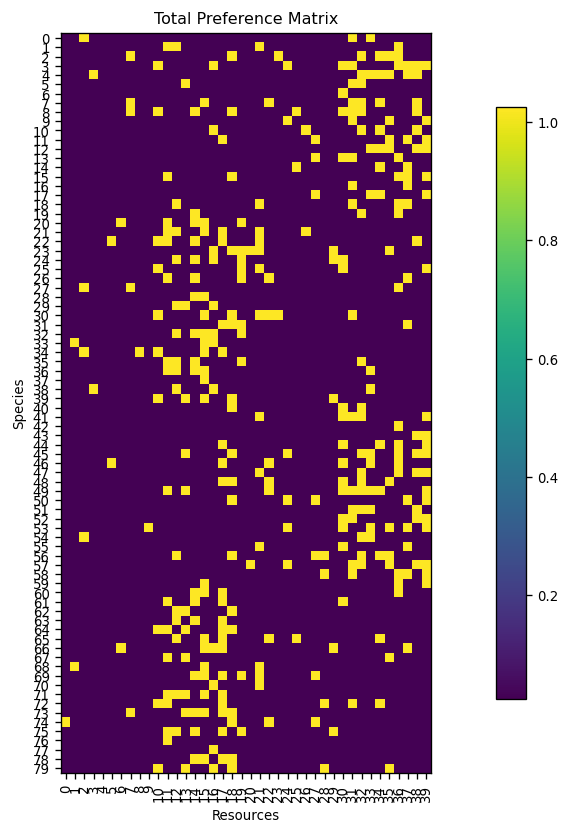

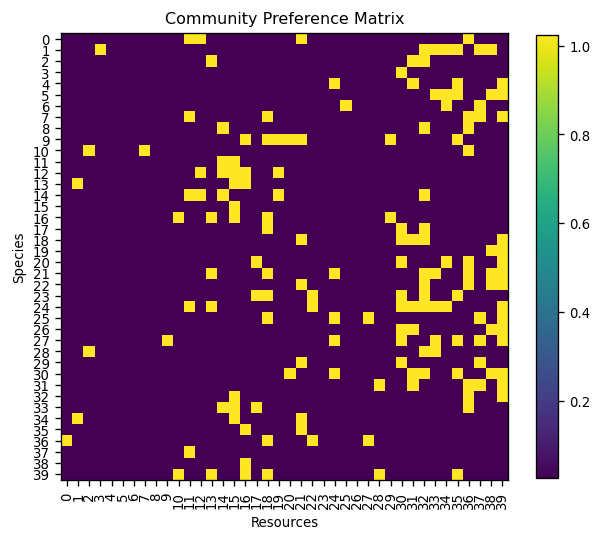

In [5]:
model.ReturnTotalPreferenceMatrix("graphical")
model.ReturnCommunityPreferenceMatrix("graphical")

In [6]:
print("Species in the community:")
model.ReturnTables("species")

Species in the community:


,Family,Preference,m
0,F0,T3,1.047144
1,F0,T3,1.047144
2,F0,T3,1.047144
3,F0,T3,1.047144
4,F0,T3,1.047144
5,F0,T3,1.047144
6,F0,T3,1.047144
7,F0,T3,1.047144
8,F0,T3,1.047144
9,F1,T1,0.880902


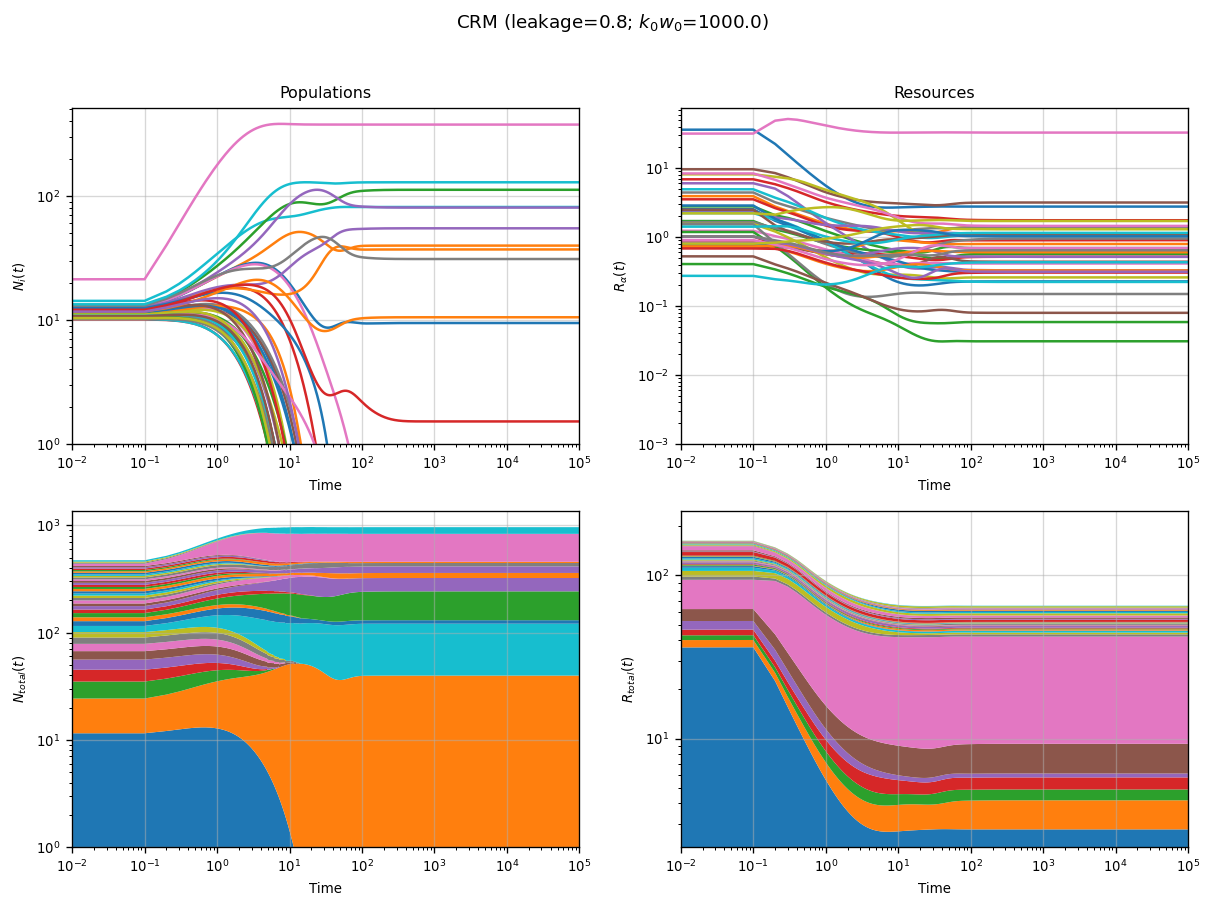

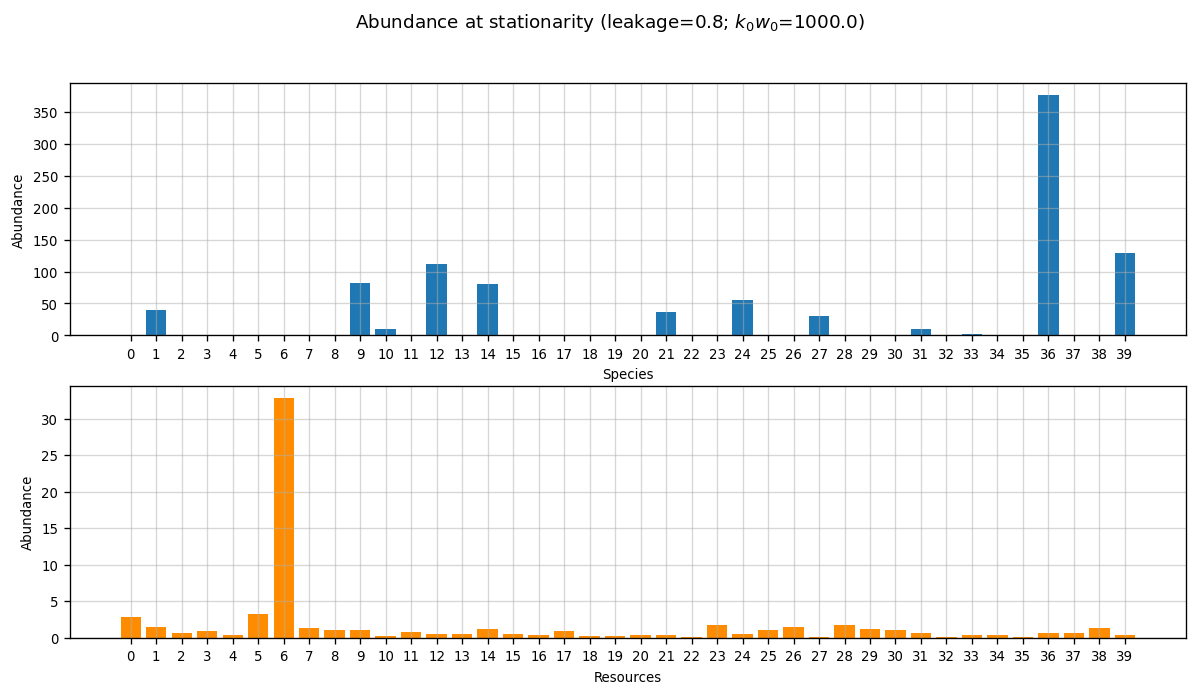

In [7]:
model.ReturnSimulationPlots()
model.ReturnAbundance()

Species Stability Time: 11.8000118000118 

Resources Stability Time: 8.8000088000088 

Niche Overlap: 0.40927277123124195 

Simpson Diversity:
 [6.18887658 6.93375051 5.73947056 9.98208327 6.88665783 5.7577727
 3.89881359 6.39975718 8.72270684 6.78149814 5.36506491 6.51906746
 5.72634739 6.18694182 5.42359554 7.70581256 5.44153653 7.12910623
 8.0500653  4.83730834 1.20913665 7.32398896 5.61584579 7.38822828
 7.38493062 6.72139411 6.20999187 5.1937735  4.56218777 6.51062838
 5.83687717 6.21317556 6.89512037 4.78095225 6.94683159 6.26175805
 7.08805666 4.7252148  6.70749443 6.60256097] 



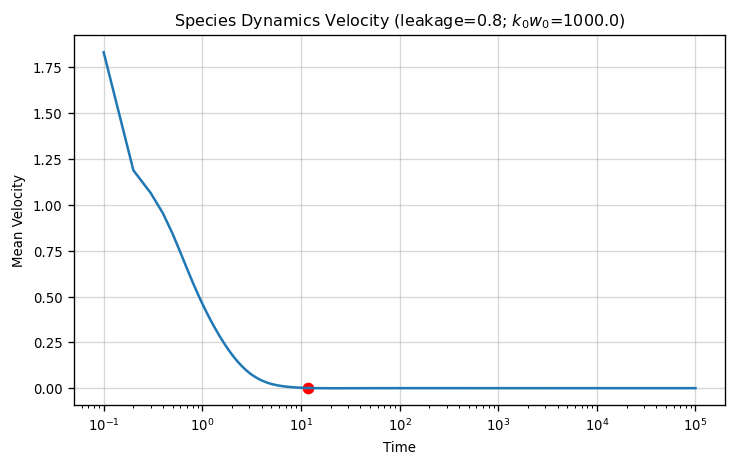

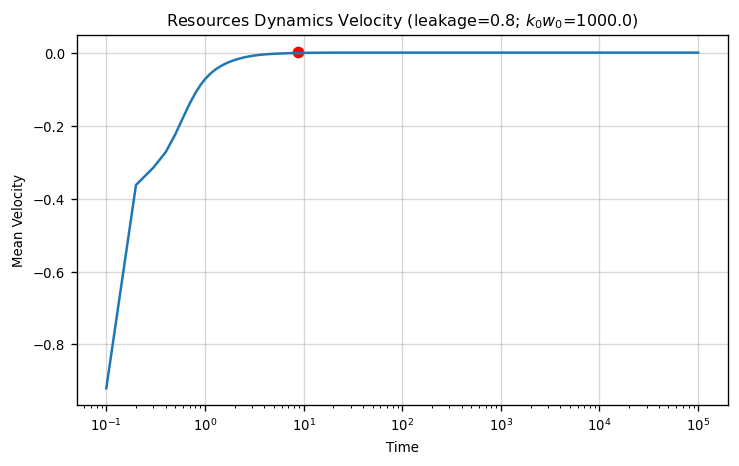

In [8]:
print("Species Stability Time:", model.StabilityTime("species",Plots=True),"\n")
print("Resources Stability Time:", model.StabilityTime("resources",Plots=True),"\n")
print("Niche Overlap:",model.ReturnNicheOverlap(),"\n")
print("Simpson Diversity:\n",model.ReturnSimpsonDiversity(),"\n")

In [9]:
last_species = model.ReturnData("species")[-1]
last_species[last_species<1]=0
last_species_index = np.nonzero(last_species)[0]

print("Surviving species:")
model.ReturnTables("species").iloc[last_species_index]

Surviving species:


,Family,Preference,m
1,F0,T3,1.047144
9,F1,T1,0.880902
10,F1,T1,0.880902
12,F1,T1,0.880902
14,F1,T1,0.880902
21,F2,T3,1.143271
24,F2,T3,1.143271
27,F2,T3,1.143271
31,F2,T3,1.143271
33,F3,T1,0.968735


<a id="42"></a>
### 4.2. Restricted Regime ($l=0.001$, $w_0k_0=10$)

For the Restricted Regime, the parameters were set to $l=0.001$ and $w_0k_0=10$. This regime corresponds to a situation with a low leakage factor and a relatively lower external energy flux. In this regime, the microbial community experiences restricted resource availability, leading to reduced richness and diversity.


Species Stability Time: 7.3000073000073 

Resources Stability Time: 0.6000006000006 

Niche Overlap: 0.40927277123124195 

Simpson Diversity:
 [1.01377392 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392
 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392
 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392
 1.01377392 1.01377392 1.52305057 1.01377392 1.01377392 1.01377392
 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392
 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392 1.01377392
 1.01377392 1.01377392 1.01377392 1.01377392] 



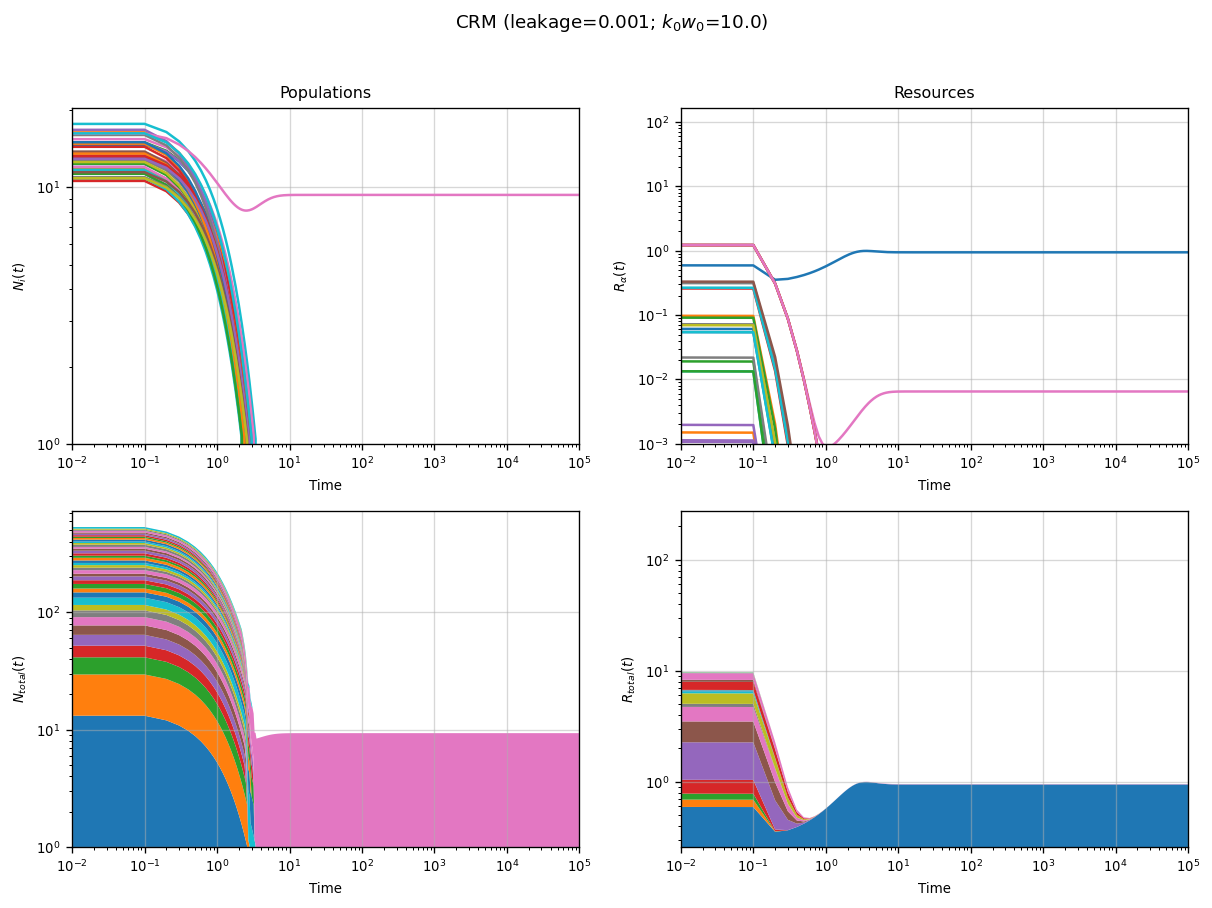

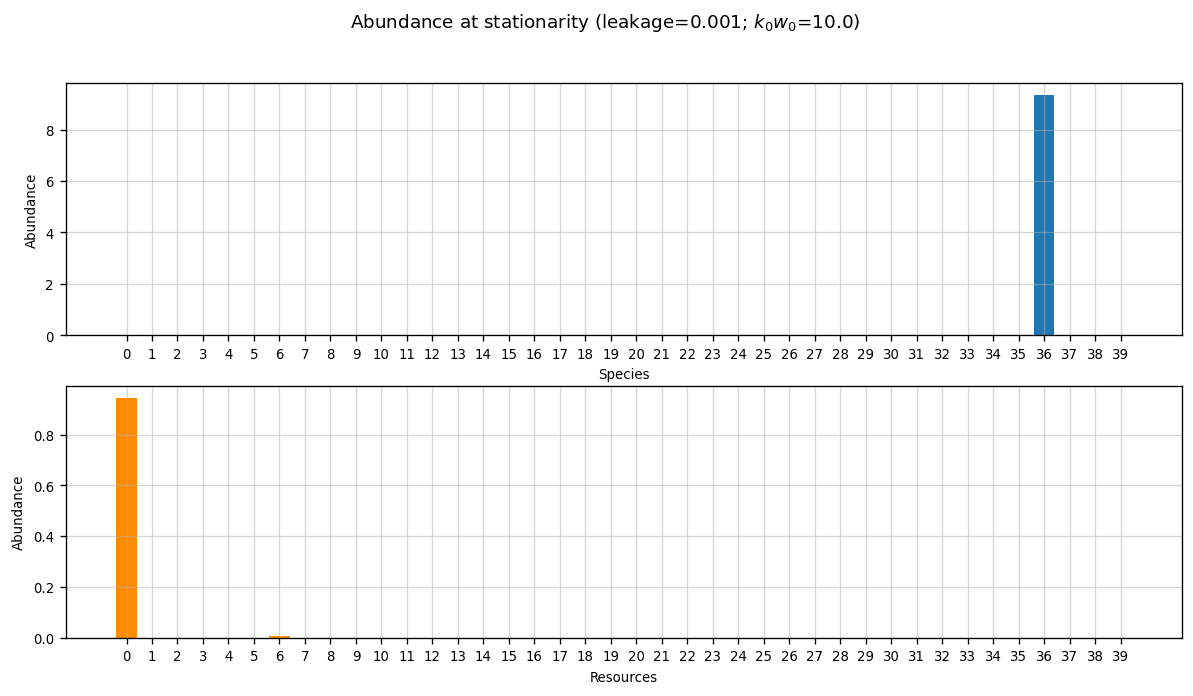

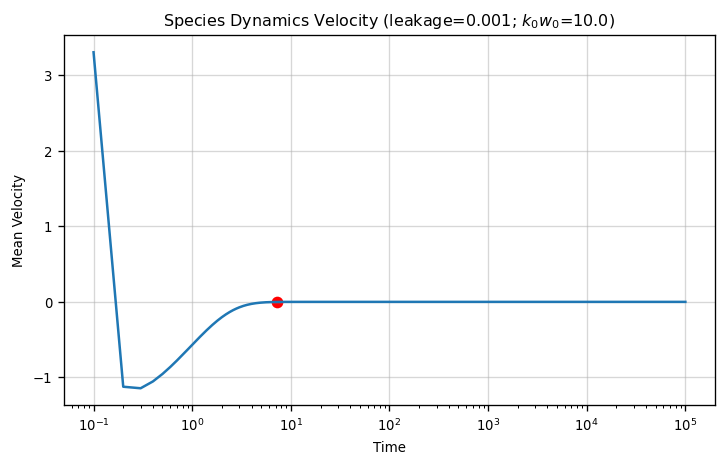

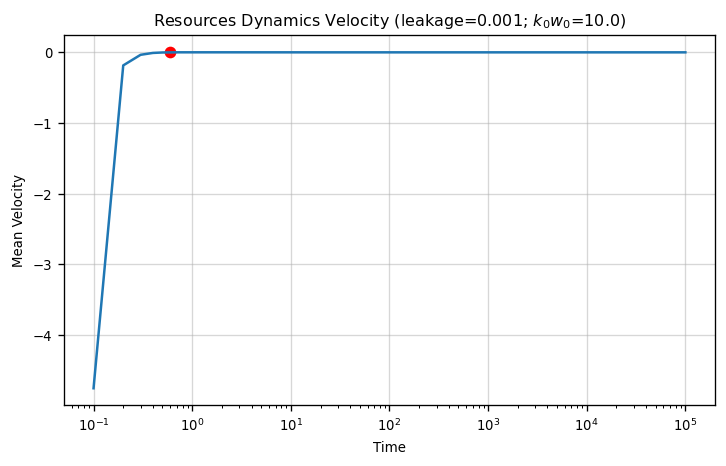

In [10]:
inputs["leakage"] = 0.001
inputs["k_0"] = 10

model=cmc3.CommunityModel(inputs)
model.ModelSeed(1234)
model.Simulate()

model.ReturnSimulationPlots()
model.ReturnAbundance()
print("Species Stability Time:", model.StabilityTime("species",Plots=True),"\n")
print("Resources Stability Time:", model.StabilityTime("resources",Plots=True),"\n")
print("Niche Overlap:",model.ReturnNicheOverlap(),"\n")
print("Simpson Diversity:\n",model.ReturnSimpsonDiversity(),"\n")

In [11]:
last_species = model.ReturnData("species")[-1]
last_species[last_species<1]=0
last_species_index = np.nonzero(last_species)[0]
last_species_index

print("Surviving species:")
model.ReturnTables("species").iloc[last_species_index]

Surviving species:


,Family,Preference,m
36,F3,T1,0.968735


<a id="5"></a>
<a href ="#main"><p style="text-align: right;">return to contents</p></a>
## 5. Simulations

To perform the simulations, ecosystems were initialized with 80 species divided into 4 families and 40 resources divided into 4 classes. From these ecosystems, communities consisting of 40 species were extracted in order to simulate stochastic coloniztion. The simulations employed a linear response function and a binary preference matrix.

In the simulations, a default externally supplied resource value of $\alpha=0$ and an associated energy density of $w_0=1$ were chosen.

For a comprehensive overview of the simulation setup, refer to the following table, which provides information on the other general parameters utilized:

In [12]:
params = pd.read_csv("phase_richness/simulation_params_phase_richness.csv")
params = pd.DataFrame(params.iloc[0].drop("Unnamed: 0"))
params.drop(["partition_F","partition_T","k","N"])

,0
S_tot,80
S,40
R,40
S0,10
R0,5
time_period,100000.0
t_step,0.1
num_F,4
num_T,4
sigma_type,linear


<a id="51"></a>
### 5.1. Stability Time

In our initial analysis, we aimed to estimate the characteristic time required for the dynamics of the system to reach stability. To accomplish this, we utilized the $\texttt{StabilityTime()}$ method implemented in the class. This method allowed us to estimate the stability time for both species and resources by analyzing the first derivative of the mean dynamics of the system.

To obtain a statistically robust estimate of the stability time, we performed simulations on two hundred and fifty communities under two different regimes: the Diverse Regime ($l=0.8$ and $w_0k_0=1000$) and the Restricted Regime ($l=0.001$ and $w_0k_0=10$).

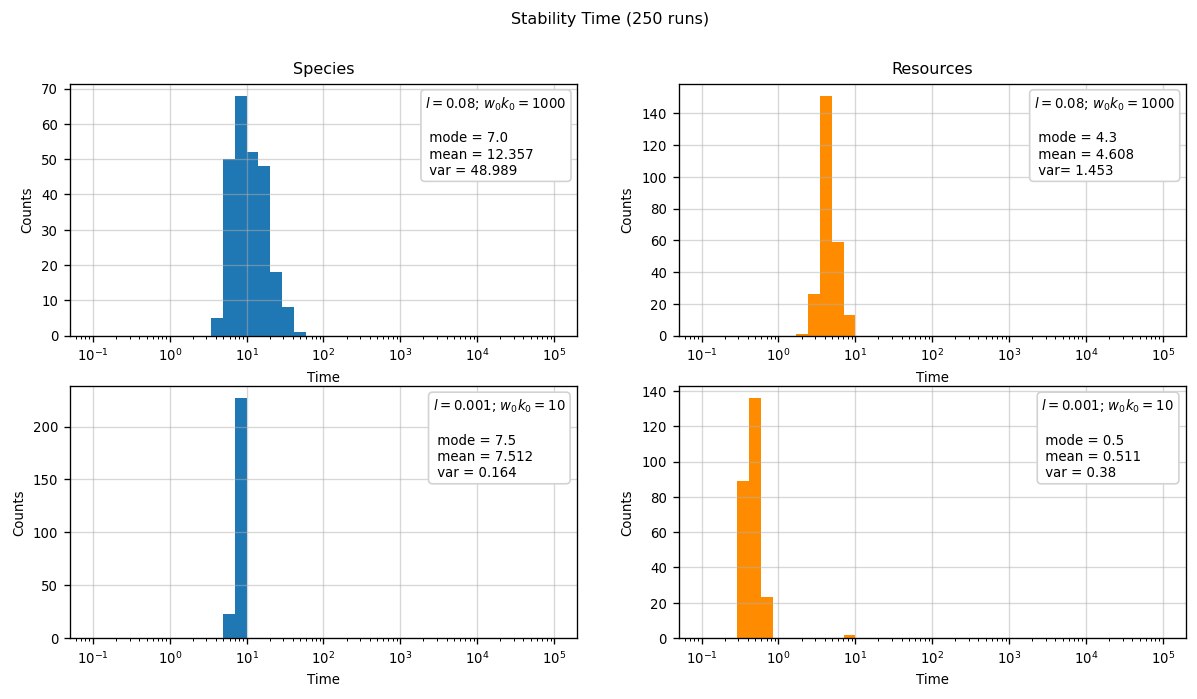

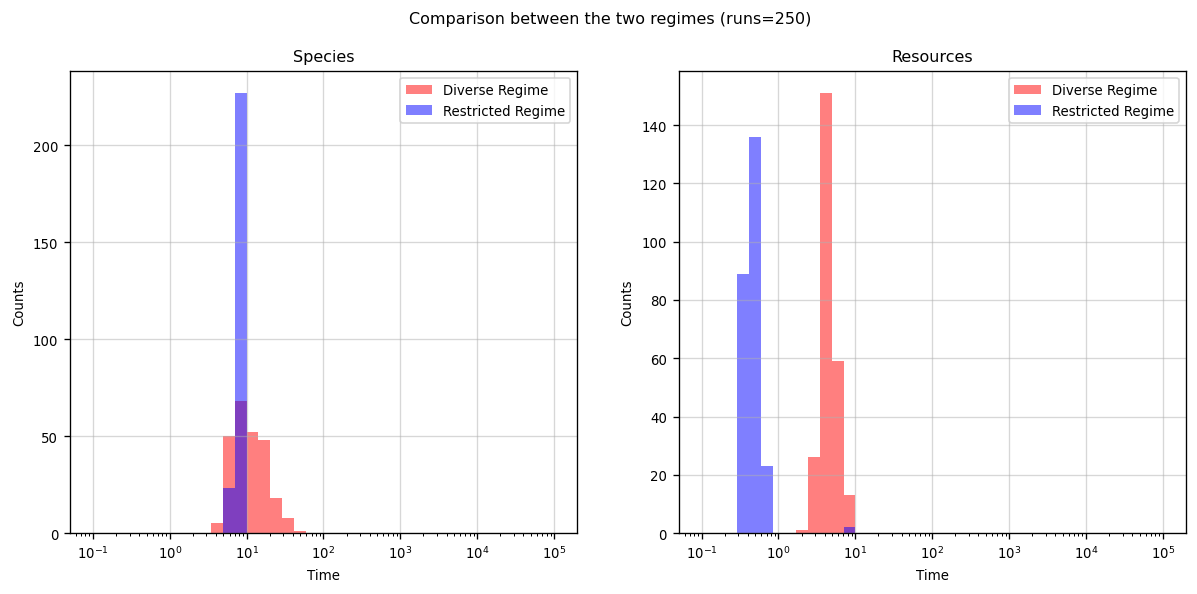

In [13]:
# get data from previous simulations (diverse regime)
DR_spec = np.genfromtxt("stability_time/DR_spec_time.csv")
DR_res = np.genfromtxt("stability_time/DR_res_time.csv")

DR_spec_mode = np.round(mode(DR_spec),3)
DR_res_mode = np.round(mode(DR_res),3)

DR_spec_mean = np.round(np.mean(DR_spec),3)
DR_res_mean = np.round(np.mean(DR_res),3)

DR_spec_var = np.round(np.var(DR_spec),3)
DR_res_var = np.round(np.var(DR_res),3)

# get data from previous simulations (restricted regime)
LR_spec = np.genfromtxt("stability_time/LR_spec_time.csv")
LR_res = np.genfromtxt("stability_time/LR_res_time.csv")

LR_spec_mode = np.round(mode(LR_spec),3)
LR_res_mode = np.round(mode(LR_res),3)

LR_spec_mean = np.round(np.mean(LR_spec),3)
LR_res_mean = np.round(np.mean(LR_res),3)

LR_spec_var = np.round(np.var(LR_spec),3)
LR_res_var = np.round(np.var(LR_res),3)


# plots
bins=np.logspace(np.log10(0.1),np.log10(inputs["time_period"]), 40)

fig, ax = plt.subplots(2,2,figsize=(12,6))
fig.suptitle("Stability Time (250 runs)")

ax[0,0].set(title="Species",xlabel="Time",ylabel="Counts")
ax[0,0].hist(DR_spec,bins=bins)
ax[0,0].set_xscale("log")
ax[0,0].text(-0.5,1.84, "$l = 0.08$; $w_0k_0 = 1000$ \n\n mode = {} \n mean = {} \n var = {}".format(DR_spec_mode,DR_spec_mean,DR_spec_var),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[0,0].grid(alpha=0.5)

ax[0,1].set(title="Resources",xlabel="Time",ylabel="Counts")
ax[0,1].hist(DR_res,bins=bins,color="darkorange")
ax[0,1].set_xscale("log")
ax[0,1].text(0.7,1.84, "$l = 0.08$; $w_0k_0 = 1000$ \n\n mode = {} \n mean = {} \n var= {}".format(DR_res_mode,DR_res_mean,DR_res_var),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[0,1].grid(alpha=0.5);

ax[1,0].set(xlabel="Time",ylabel="Counts")
ax[1,0].hist(LR_spec,bins=bins)
ax[1,0].set_xscale("log")
ax[1,0].text(-0.485,0.64, "$l = 0.001$; $w_0k_0 = 10$ \n\n mode = {} \n mean = {} \n var = {} ".format(LR_spec_mode,LR_spec_mean,LR_spec_var),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[1,0].grid(alpha=0.5)

ax[1,1].set(xlabel="Time",ylabel="Counts")
ax[1,1].hist(LR_res,bins=bins,color="darkorange")
ax[1,1].set_xscale("log")
ax[1,1].text(0.715,0.64, "$l = 0.001$; $w_0k_0 = 10$ \n\n mode = {} \n mean = {} \n var = {}".format(LR_res_mode,LR_res_mean,LR_res_var),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[1,1].grid(alpha=0.5)


fig, ax = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Comparison between the two regimes (runs=250)")

ax[0].set(title="Species",xlabel="Time",ylabel="Counts")
ax[0].hist(DR_spec,bins=bins,label="Diverse Regime",alpha=0.5,color="red")
ax[0].hist(LR_spec,bins=bins,label="Restricted Regime",alpha=0.5,color="blue")
ax[0].set_xscale("log")
ax[0].grid(alpha=0.5)
ax[0].legend()

ax[1].set(title="Resources",xlabel="Time",ylabel="Counts")
ax[1].hist(DR_res,bins=bins,label="Diverse Regime",alpha=0.5,color="red")
ax[1].hist(LR_res,bins=bins,label="Restricted Regime",alpha=0.5,color="blue")
ax[1].set_xscale("log")
ax[1].grid(alpha=0.5)
ax[1].legend();

In the Diverse Regime, the average stability time for species was found to be approximately 12 time units. The mode of 7.0 suggests a prominent peak in the distribution of stability times, indicating a common stabilization period for a significant number of species. The relatively high variance of 48.989 reflects a wide range of stability times among the species, indicating substantial variation in the time needed for different species to reach stability.

For resources in the Diverse Regime, both the average and mode stability time were approximately 4 time units, indicating that resources tend to reach a stationary state faster than species. The variance of 1.453 indicates a moderate degree of variability in the stability times among the resources.

In the Restricted Regime, the stability time distribution for species exhibited a narrower range, with a mean stability time of 7.5 time units and a low variance of 0.164. This suggests that, in this regime, the majority of species tend to become extinct relatively quickly, leading to a more consistent and synchronized stabilization process within the community.

For resources in the Restricted Regime, the average stability time was approximately 0.5 time units, indicating that resources in this regime reach a stationary state relatively quickly. The relatively high variance of 0.38 implies a moderate degree of variability in the stability times among the resources.

These results provide important insights into the dynamics of species and resources within microbial communities under different regimes. The Diverse Regime, characterized by high leakage and substantial external energy flux, exhibits longer and more variable stability times for both species and resources. In contrast, the Restricted Regime, characterized by low leakage and low external energy flux, shows shorter and more consistent stability times for both species and resources.

<a id="52"></a>
### 5.2. Mean richness and Mean Simpson diversity

To better understand these two regimes, we examined the functional traits of members of typical communities in each one. In the Restricted Regime, many surviving species derive most of their energy directly from the externally supplied resource. In the Diverse Regime, by contrast, only a minority of the steady-state community members can consume this resource at all, and even these species receive most of their energy from a diverse array of metabolic byproducts. 

In order to characterize this two regimes, we observed at stationarity the mean richness and the mean Simpson diversity for different combinations of leakages and external supplied energy.

The richness is a measure of the number of different species present in our community, while the Simpson diversity is defined as:

$$
M_i^{eff}=\left[ \sum_{\alpha}\left(\frac{J_{i\alpha}^{in}}{J_{i}^{in}}\right)^2\right]^{-1}
$$

where $J_{i\alpha}^{in}$ is the incoming resource flux vector which measures the effective number of resources consumed by each species, and $J_{i}^{in}=\sum_\alpha J_{i\alpha}^{in}$ is the total incoming energy flux for each cell of this species. $M_i^{eff}$ approaches 1 for species that obtain the bulk of their energy from a single resource type and approaches $M$ when all resource types are consumed equally.

To obtain the following heatmaps, we performed one hundred simulations by linearly varying the leakage parameter from 0.001 to 0.9 and logarithmically the parameter $k_0$ from 1 to 1000.

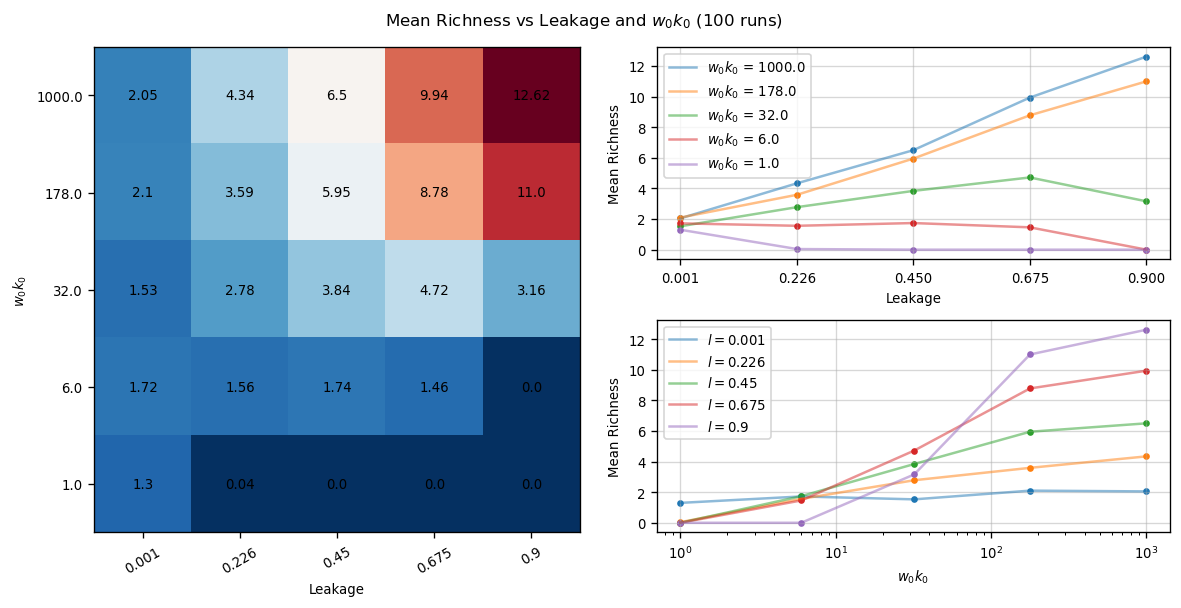

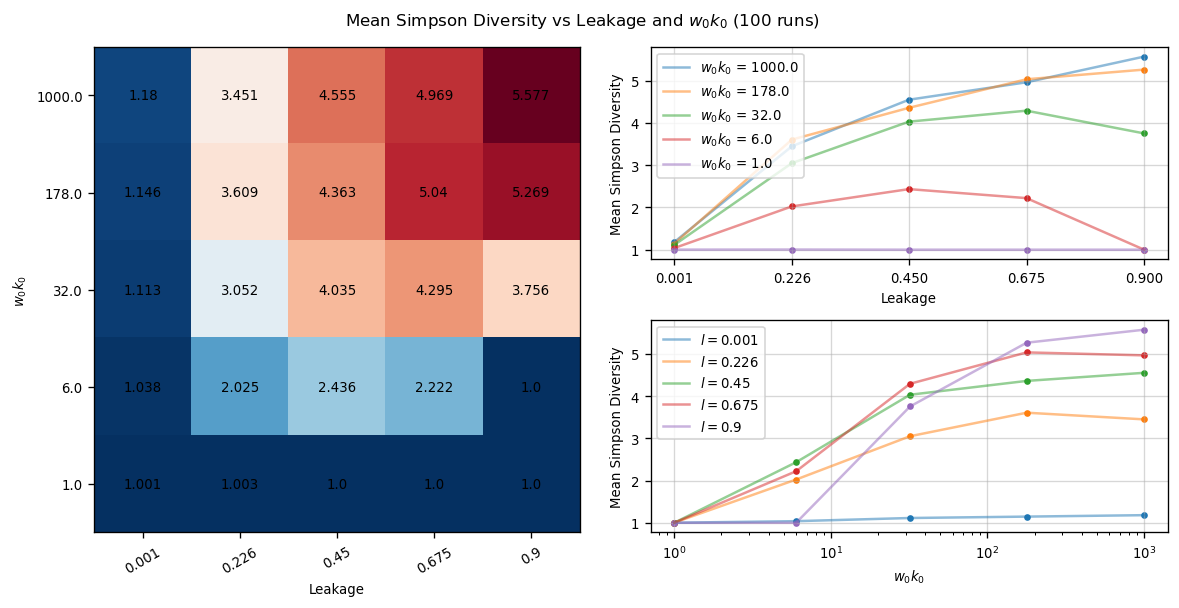

In [14]:
def hm_plots(mean_matrix,ax_label,lab,title):    
    fig = plt.figure(tight_layout=True, figsize=(10,5))
    gs = gridspec.GridSpec(2, 2, height_ratios=(1,1))
    fig.suptitle("Mean {} vs Leakage and ".format(title) + ax_label + " (100 runs)",fontsize=10)

    ax = fig.add_subplot(gs[:, 0])
    ax.imshow(mean_matrix, cmap="RdBu_r")
    ax.set_xlabel("Leakage")
    ax.set_ylabel(ax_label)

    for i in range(len(wk)):
        for j in range(len(leakage)):
            ax.annotate(np.round(mean_matrix[i, j],3), xy=(j, i), ha='center', va='center', color='black') 
    ax.set_xticks(range(len(leakage)), leakage, rotation=30)
    ax.set_yticks(range(len(wk)), wk)

    ax = fig.add_subplot(gs[0, 1])
    ax.grid(alpha=0.5)
    for i,j in zip(range(len(wk)),wk):
        ax.scatter(leakage,mean_matrix[i],marker=".")
        ax.plot(leakage,mean_matrix[i],label= lab + " = {}".format(j),alpha=0.5)
        ax.set_xticks(leakage)
        ax.set_xlabel("Leakage")
        ax.set_ylabel("Mean {}".format(title))
        ax.legend(loc=2,fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    ax.grid(alpha=0.5)
    for i,j in zip(range(mean_matrix.shape[0]),leakage):
        ax.scatter(wk,mean_matrix[:,i],marker=".")
        ax.plot(wk,mean_matrix[:,i],label="$l=${}".format(j),alpha=0.5)
        ax.set_xlabel(ax_label)
        ax.set_ylabel("Mean {}".format(title))
        ax.set_xscale("log")
        ax.legend(loc=2,fontsize=8)


leakage=np.round(np.linspace(0.001,0.9,num=5),3)
wk=np.logspace(0, 3, num=5, base=10)
wk=np.round(wk,0)
wk=wk[::-1]


# get data from previous simulations (richness)
mean_matrix_1_resource = np.genfromtxt("grid_search_richness/mean_richness_1_resources.csv", delimiter=",")
hm_plots(mean_matrix_1_resource,"$w_0k_0$","$w_0k_0$","Richness")

# get data from previous simulations (simpson diversity)
mean_diversity_1_resource = np.genfromtxt("grid_search_diversity/mean_diversity_1_resources.csv", delimiter=",")
hm_plots(mean_diversity_1_resource,"$w_0k_0$","$w_0k_0$","Simpson Diversity")

The observations reveal distinct trends in both richness and Simpson diversity as the leakage factor increases, while considering a fixed value of $w_0k_0$.

For $w_0k_0$ values of 178 and 1000, both richness and Simpson diversity exhibit a monotonically increasing trend with increasing leakage. As expected, the growth of the leakage factor for high values of incoming energy flux leads to greater resources presence from microbial community resources. This increase leads to a reduction in competition within the community resulting in an increase in richness and diversity.

However, for $w_0k_0$ values of 32 and 6, the resulting curves display a negative concavity. Specifically, the first curve reaches a maximum for both richness and Simpson diversity at a leakage factor of 0.675, while the second curve achieves a maximum at a leakage factor of 0.45. This trend shows that for intermediate values of $w_0k_0$ there is an optimal leakage value which allows the bacterial community to increase the resources present in the environment without however detrimenting the amount of energy necessary for the maintenance of the single species.

When $w_0k_0$ is equal to 1, richness decreases immediately, approaching zero, while Simpson diversity remains constant at 1. In fact, in this configuration, even small values of leakage mean that the species involved are unable to retain the energy sufficient for their maintenance with consequent extinction of the same. The extinction of species also implies that the only resource available in the environment is that supplied externally.

Shifting the perspective and maintaining a fixed leakage value, it is observed that for a leakage factor of 0.001, richness experiences slight growth as the external energy input increases, while Simpson diversity remains nearly constant at 1. For subsequent leakage values, richness demonstrates a monotonous growth pattern. At higher leakage values, the curve adopts a more pronounced sigmoid shape. Simpson diversity follows a similar trend, except for leakage factors of 0.226 and 0.675, where a maximum is observed at $w_0k_0$ equal to 178. The emergence of a sigmoid-like trend suggests that there be a threshold beyond which increasing energy input has diminishing effects on richness and diversity.



<a id="53"></a>
### 5.3. Niche Overlap

We have observed from previous simulations how, in the case of the Restricted Regime, the number of surviving species is limited due to a low metabolic leakage or a low energy supply in the environment. However, there seems to be a limitation even in the Diverse Regime, despite having high energy supply and leakage values. In fact, although the competitive exclusion principle imposes a theoretical limit on the number of resources, the average number of surviving species at equilibrium is much lower. 

This phenomenon can be explained by the preference matrix and the similarity in preferences among species. If multiple species have similar preferences, only one of them is destined to outcompete the others. Let us calculate the degree of similarity in our environment using Niche Overlap, computed as follows:

$$
\left\langle\rho_{i j}\right\rangle \equiv\left\langle\frac{\sum_\alpha c_{i \alpha} c_{j \alpha}}{\sqrt{\sum_\alpha c_{i \alpha}^2 \sum_\alpha c_{j \alpha}^2}}\right\rangle=\frac{\left\langle c_{i \alpha}\right\rangle^2}{\sqrt{\left\langle c_{i \alpha}^2\right\rangle\left\langle c_{j \alpha}^2\right\rangle}}
$$

In our simulations, it is possible to adjust the similarity of the preference matrix and, thus, the value of the Niche Overlap, through the parameter $c_1$, as explained earlier. We logarithmically varied the value of $c_1$ from 1 to 0.33, starting with highly heterogeneous preference matrices and gradually transitioning to more homogeneous ones with similar preferences among species.

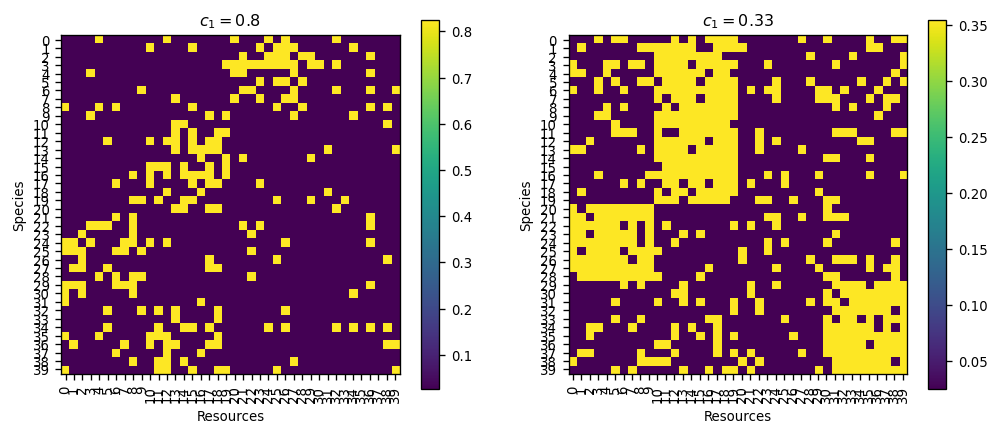

In [15]:
inputs["k_0"] = 10
inputs["leakage"] = 0.001

c1_ex1, c1_ex2 = 0.33, 0.8
inputs["c_1"] = c1_ex1
model_ex1 = cmc3.CommunityModel(inputs)
model_ex1.Simulate()
inputs["c_1"] = c1_ex2
model_ex2 = cmc3.CommunityModel(inputs)
model_ex2.Simulate()

fig, ax = plt.subplots(1, 2, figsize=(10,5))
model_ex1.ReturnCommunityPreferenceMatrix("graphical", figsize=(4,4), title=f'$c_1 = {c1_ex1}$', ax=ax[1])
model_ex2.ReturnCommunityPreferenceMatrix("graphical", figsize=(4,4), title=f'$c_1 = {c1_ex2}$', ax=ax[0])

Therefore, we expect that as the preferences among species become increasingly similar, the value of the Richness will decrease due to escalating competition among species.

We set up twenty preference matrices with high homogeneity, resulting in low Niche Overlap, and conducted simulations in two environments: ten in Diverse Regime and ten in Restricted Regime. Subsequently, we gradually decreased the value of $c_1$ (thus making the matrices increasingly homogeneous). The graphs below depict the simulations described above.

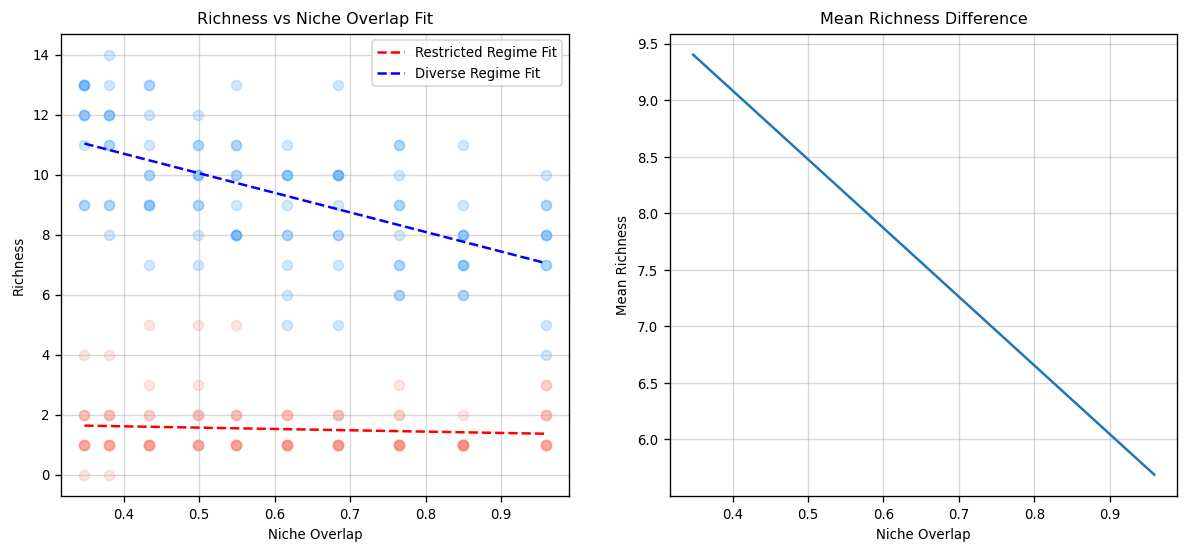

In [16]:
def lin_func(x, m, q):
    return q + m * x

# get data from previous simulations 
dir_name = 'NicheOverlap_data'

Niches_DR = np.loadtxt(f'{dir_name}/Niches_RR.csv', delimiter=',')
Niches_RR = np.loadtxt(f'{dir_name}/Niches_DR.csv', delimiter=',')
survived_array_RR = np.loadtxt(f'{dir_name}/survived_array_RR.csv', delimiter=',')
survived_array_DR = np.loadtxt(f'{dir_name}/survived_array_DR.csv', delimiter=',')

popt_RR = np.loadtxt(f'{dir_name}/popt_RR.csv', delimiter=',')
popt_DR = np.loadtxt(f'{dir_name}/popt_DR.csv', delimiter=',')

num_simulations = survived_array_DR.shape[0]
Niches_RR = list(Niches_RR)
Niches_DR = list(Niches_DR)

x_RR = np.linspace(np.min(Niches_RR), np.max(Niches_RR), num=100)
y_RR = lin_func(x_RR, popt_RR[0], popt_RR[1])
x_DR = np.linspace(np.min(Niches_DR), np.max(Niches_DR), num=100)
y_DR = lin_func(x_DR, popt_DR[0], popt_DR[1])
distance = y_DR-y_RR

# plot
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].set(title='Richness vs Niche Overlap Fit',xlabel='Niche Overlap',ylabel='Richness')
ax[0].scatter(Niches_RR*num_simulations, survived_array_RR.flatten(), c='salmon', alpha=0.2)
ax[0].scatter(Niches_DR*num_simulations, survived_array_DR.flatten(), c='dodgerblue', alpha=0.2)
ax[0].plot(x_RR, y_RR, 'r--', label='Restricted Regime Fit')
ax[0].plot(x_DR, y_DR, 'b--', label='Diverse Regime Fit')
ax[0].legend()
ax[0].grid(alpha=0.5)

ax[1].set(title='Mean Richness Difference',xlabel='Niche Overlap',ylabel='Mean Richness')
ax[1].plot(x_DR,distance)
#ax[1].set_ylim(0,10)
ax[1].grid(alpha=0.5)

The left graph highlights the average richness as a function of niche overlap. As expected, in the Diverse Regime, as species competitiveness increases, the number of surviving species decreases linearly, as $N_\text{Richness}\sim - 6.67 \cdot n_\text{overlap}$. The same negative trend is present in the Restricted Regime, albeit almost imperceptibly. This emphasizes that the lack of energy provided by the environment and low leakage are dominant factors for species survival.

Furthermore, it can be observed that in the case of maximum competitiveness (Niche Overlap $\sim$ 1), the two regimes still maintain a certain difference in the average number of surviving species. This further confirms that environmental factors dominate species competitiveness and that a thriving environment mitigates the effect of competition.

### 5.4. Mean Richness with multiple external resources

In this section, our focus is to investigate the impact of multiple external resources on the richness of the microbial communities at stationary state. To visualize and analyze this relationship, we generated heatmaps. For consistency, we maintained the same leakage and $k_\alpha$ values as previously mentioned. In this case, we assumed an energy density $w_\alpha$ of 1 for all the external resources under consideration.

To ensure diversity and differentiation among the external resources, we assigned each resource to a distinct resource class out of the four available in the ecosystem. This approach allows us to examine the influence of multiple external resources originating from different resource classes on the resulting richness patterns.

By constructing the heatmaps, we can observe how variations in the combinations of external resources across different classes affect the richness of the microbial communities. This analysis provides insights into the role of resource diversity and composition in shaping the community structure and dynamics.

It is worth noting that by setting the energy density $w_\alpha$ to the same value for all the external resources, we ensure that each resource contributes equally in terms of their energy supply to the system. This allows for a fair comparison and evaluation of the influence of multiple external resources on richness.

<a id="541"></a>
#### 5.4.1. Two external resources ($\alpha=0,10$)

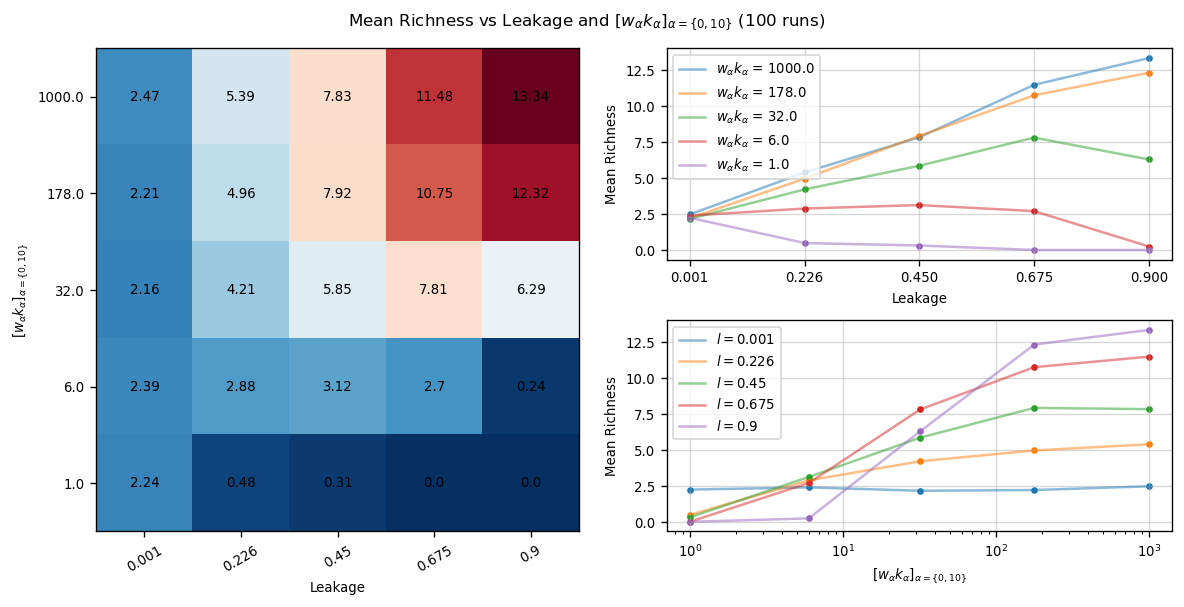

In [17]:
mean_matrix_2_resource = np.genfromtxt("grid_search_richness_2_resources/mean_richness_2_resources.csv", delimiter=",")
hm_plots(mean_matrix_2_resource,r"$[w_\alpha k_\alpha]_{\alpha=\{0,10\}}$",r"$w_\alpha k_\alpha$","Richness")

<a id="542"></a>
#### 5.4.2. Three external resources ($\alpha=0,10,20$)


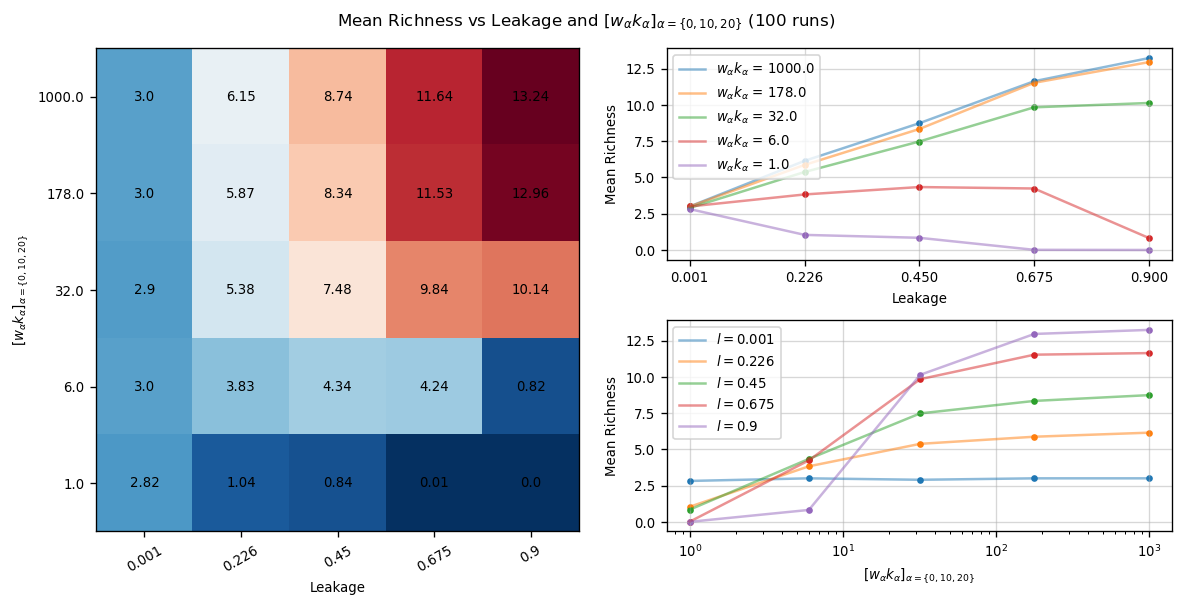

In [18]:
mean_matrix_3_resource = np.genfromtxt("grid_search_richness_3_resources/mean_richness_3_resources.csv", delimiter=",")
hm_plots(mean_matrix_3_resource,r"$[w_\alpha k_\alpha]_{\alpha=\{0,10,20\}}$",r"$w_\alpha k_\alpha$","Richness")

<a id="543"></a>
#### 5.4.3. Four external resources ($\alpha=0,10,20,30$)

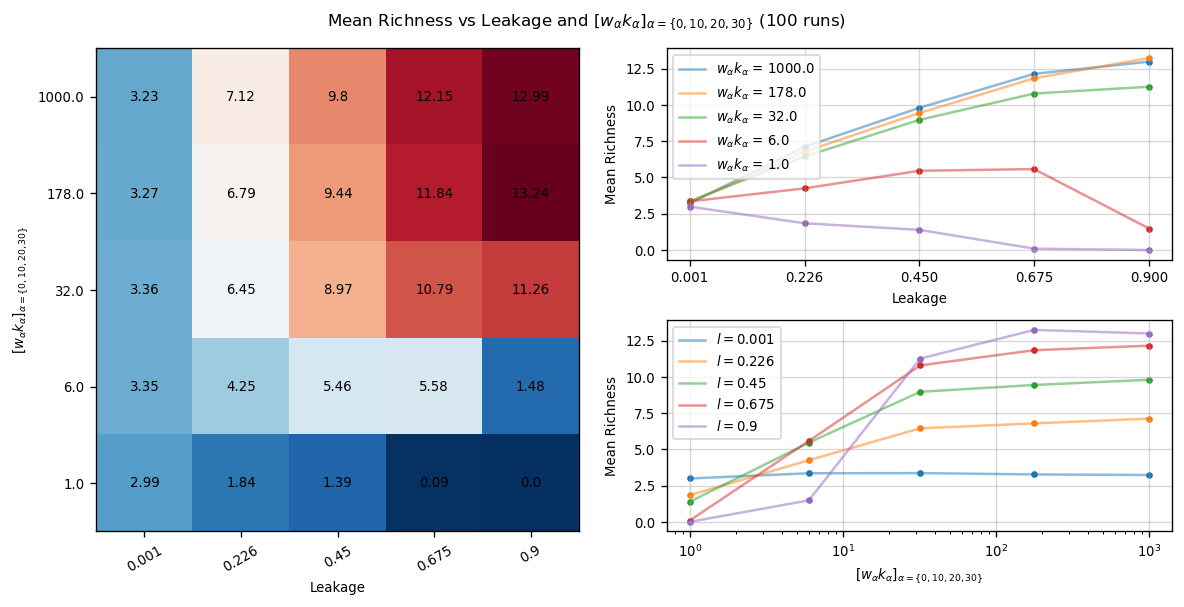

In [19]:
mean_matrix_4_resource = np.genfromtxt("grid_search_richness_4_resources/mean_richness_4_resources.csv", delimiter=",")
hm_plots(mean_matrix_4_resource,r"$[w_\alpha k_\alpha]_{\alpha=\{0,10,20,30\}}$",r"$w_\alpha k_\alpha$","Richness")

<a id="554"></a>
#### 5.5.4. Multiple external resources comparison



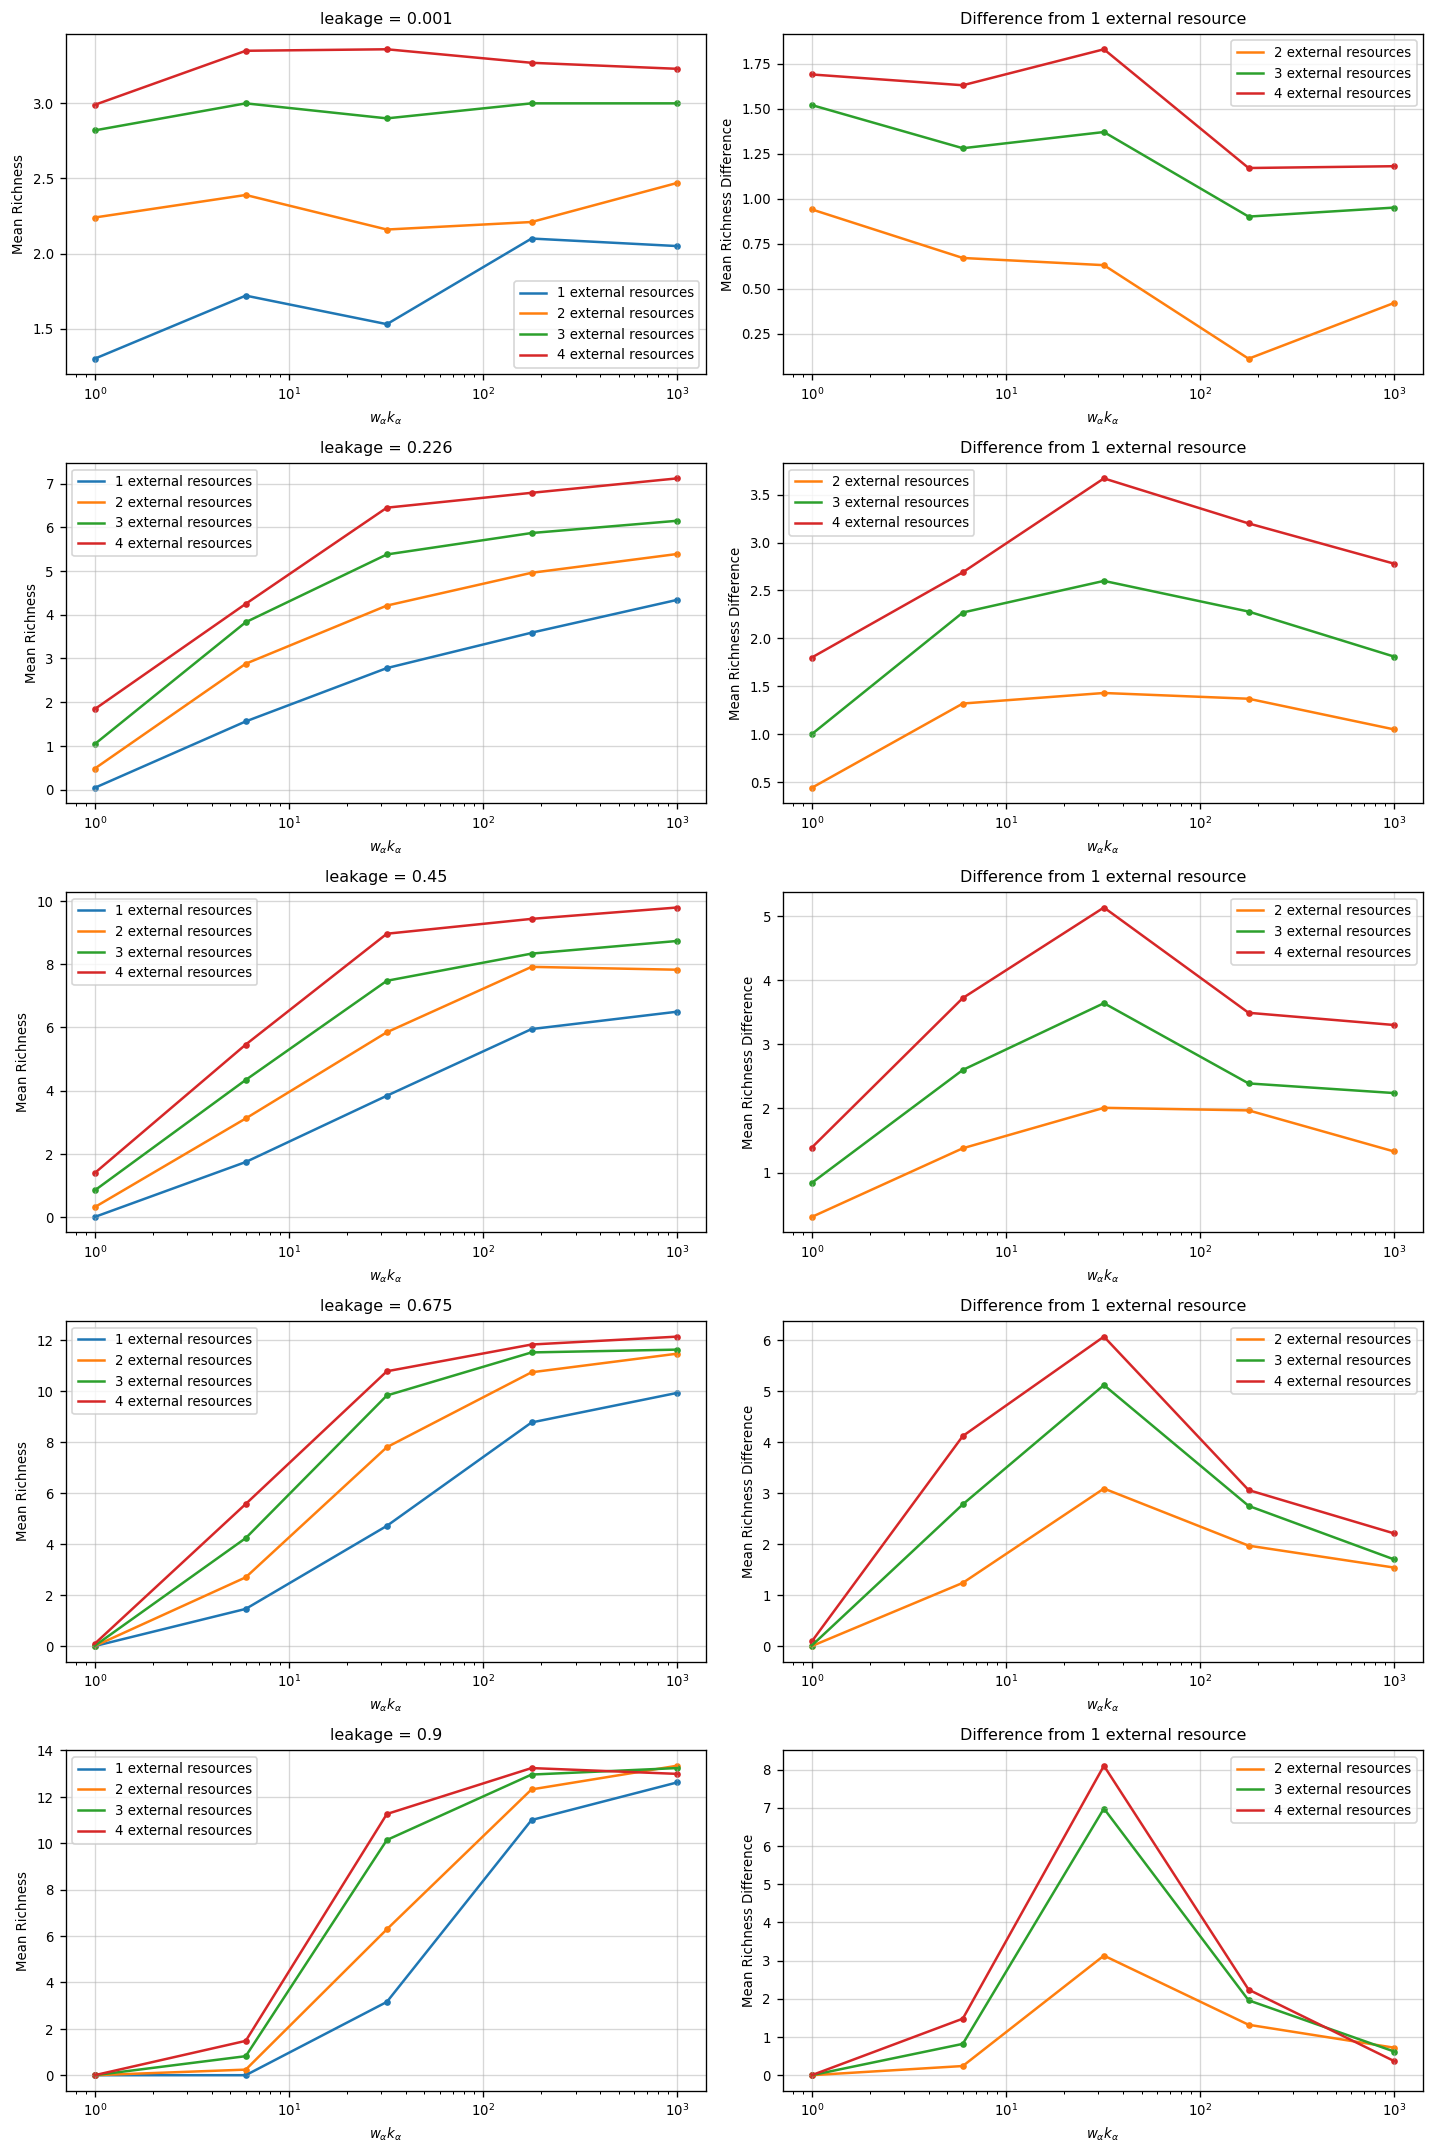

In [20]:
mean_matrices = [mean_matrix_1_resource, mean_matrix_2_resource, mean_matrix_3_resource, mean_matrix_4_resource]

def calculate_abs_diff(column_index):
    l = np.array([mean_matrices[i][:, column_index] for i in range(len(mean_matrices))])
    abs_diff = np.abs(l[0] - l[1:])
    return abs_diff

l_0001 = np.array([mean_matrices[i][:, 0] for i in range(len(mean_matrices))])
l_0226 = np.array([mean_matrices[i][:, 1] for i in range(len(mean_matrices))])
l_045 = np.array([mean_matrices[i][:, 2] for i in range(len(mean_matrices))])
l_0675 = np.array([mean_matrices[i][:, 3] for i in range(len(mean_matrices))])
l_09 = np.array([mean_matrices[i][:, 4] for i in range(len(mean_matrices))])

abs_diff_0001 = calculate_abs_diff(0)
abs_diff_0226 = calculate_abs_diff(1)
abs_diff_045 = calculate_abs_diff(2)
abs_diff_0675 = calculate_abs_diff(3)
abs_diff_09 = calculate_abs_diff(4)


def comparison_plots(data_sets, leakage_values):
    colors = ["tab:orange", "tab:green", "tab:red"]
    num_plots = len(data_sets)

    fig, axes = plt.subplots(num_plots, 2, figsize=(12, 18))

    for i in range(num_plots):
        l_00 = data_sets[i][0]
        abs_diff_00 = data_sets[i][1]
        leakage = leakage_values[i]
        ax1 = axes[i, 0]
        ax2 = axes[i, 1]

        ax1.set_title("leakage = {}".format(leakage))
        ax1.set_xlabel(r"$w_\alpha k_\alpha$")
        ax1.set_ylabel("Mean Richness")

        for j in range(l_00.shape[0]):
            ax1.plot(wk, l_00[j], label="{} external resources".format(j+1))
            ax1.scatter(wk, l_00[j], marker=".")

        ax1.set_xscale("log")
        ax1.grid(alpha=0.5)
        ax1.legend(fontsize=8)

        ax2.set_title("Difference from 1 external resource")
        ax2.set_xlabel(r"$w_\alpha k_\alpha$")
        ax2.set_ylabel("Mean Richness Difference")

        for j in range(abs_diff_00.shape[0]):
            ax2.plot(wk, abs_diff_00[j], c=colors[j], label="{} external resources".format(j+2))
            ax2.scatter(wk, abs_diff_00[j], marker=".", c=colors[j])

        ax2.set_xscale("log")
        ax2.grid(alpha=0.5)
        ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


data_sets=[(l_0001, abs_diff_0001),(l_0226, abs_diff_0226),(l_045, abs_diff_045),(l_0675, abs_diff_0675),(l_09, abs_diff_09)]
leakage_values=[0.001,0.226,0.45,0.675,0.9]

comparison_plots(data_sets, leakage_values)

In the left-hand column of the observed data, the mean richness curves are plotted as a function of the external energy flux while keeping the leakage values constant. On the right-hand column, the average difference of the richness is shown relative to the case with a single external resource.

It is notable that, similar to the previous observation, the average richness exhibits a pronounced sigmoidal trend as the leakage factor increases. This suggests that the relationship between richness and the external energy flux becomes increasingly nonlinear with higher leakage values.

Regarding the average difference of the richness compared to the case with a single external resource, an interesting finding is that as the leakage factor increases, this difference tends to be larger for intermediate values of $w_{\alpha}k_{\alpha}$. This indicates that the presence of multiple external resources leads to greater variations in richness compared to the scenario with a single resource. However, for extreme values of $w_{\alpha}k_{\alpha}$, the difference tends to converge to the same value. This suggests that the influence of additional external resources on richness becomes less significant in situations where the energy flux is extremely high or low.

These observations highlight the complex relationship between external energy flux, leakage factor, and richness in microbial communities. The sigmoidal trend in average richness with increasing leakage implies a nonlinear response to changes in resource availability. 

<a id="55"></a>
### 5.5. High leakage behavior with a single external resource

In this section, we focused on examining the behavior of the average richness in the system under high leakage conditions when a single external resource is present. We observed that the average richness exhibits a sigmoid-like trend as a function of $w_0k_0$. To further investigate this behavior, we conducted a series of simulations using thirty logarithmically distributed values of $w_0k_0$ ranging from 0 to 1000.

For each value of $w_0k_0$, we performed ten simulations while maintaining fixed leakage values between 0.8 and 0.99. The resulting data points, obtained as the average of the ten simulations, were then fitted with a sigmoid function to characterize the observed trend. The sigmoid function used for fitting is defined as:

$$
f(x) = \frac{L}{1 + e^{-k(x - x_0)}} + b
$$

Below, we present three examples of curve fits that illustrate the observed trend in the relationship between the average richness and $w_0k_0$.

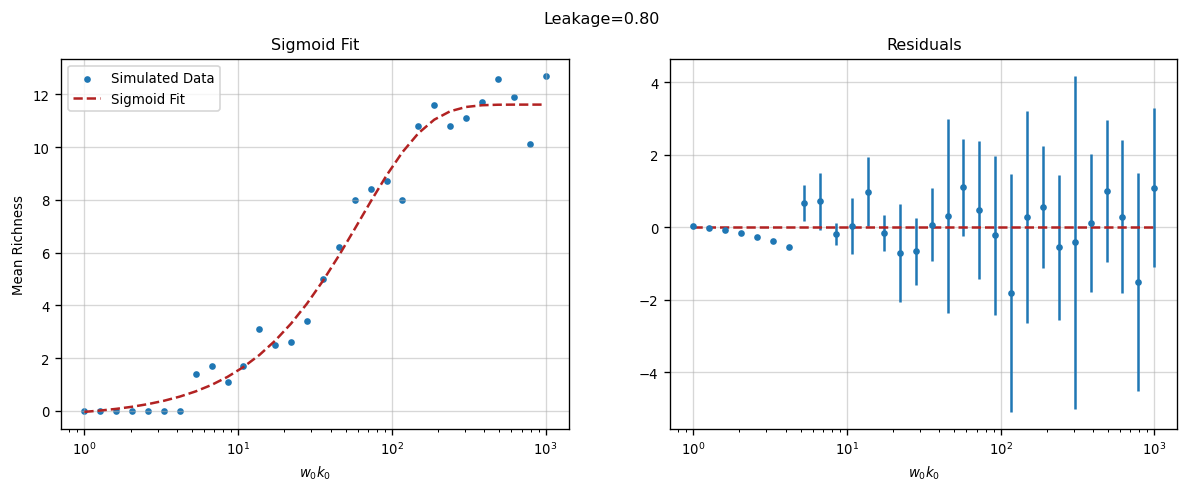

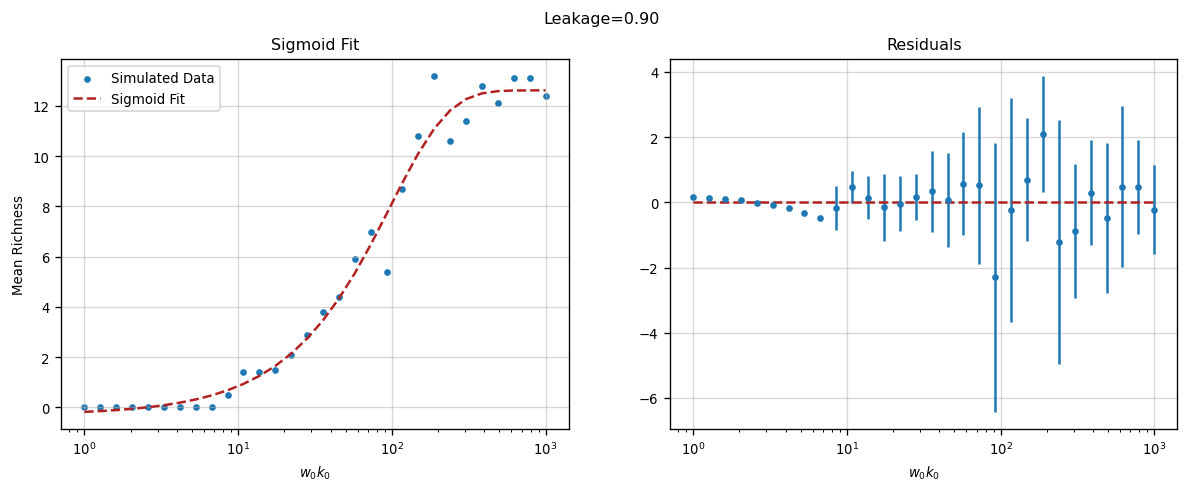

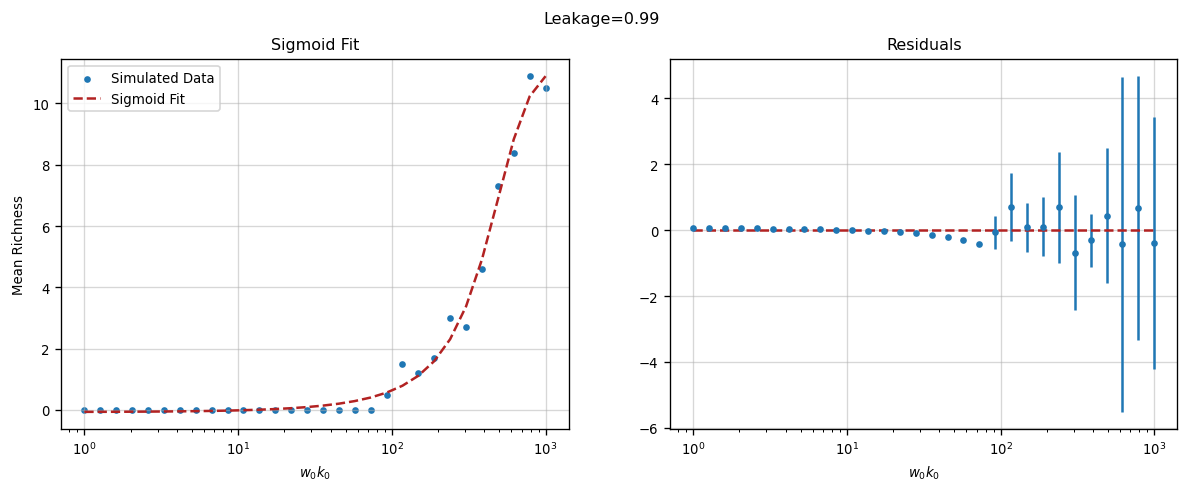

In [21]:
def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return y

wk_fine = np.logspace(0, 3, num=30, base=10)
data = {}

for i in range(80, 97, 2):
    file_name = f"phase_richness/phase_richness_sim10_l{i}.csv"
    fit_params_file = f"phase_richness/fit_params_phase_richness_sim10_l{i}.csv"

    results = np.genfromtxt(file_name, delimiter=",")
    mean_results = results[:, 0]
    std_results = results[:, 1]
    fit_params = np.genfromtxt(fit_params_file, delimiter=",")
    fit = sigmoid(wk_fine, *fit_params)
    residuals = mean_results - fit

    data[f"results_{i}"] = results
    data[f"mean_results_{i}"] = mean_results
    data[f"std_results_{i}"] = std_results
    data[f"fit_params_{i}"] = fit_params
    data[f"fit_{i}"] = fit
    data[f"residuals_{i}"] = residuals

for i in range(97, 100):
    file_name = f"phase_richness/phase_richness_sim10_l{i}.csv"
    fit_params_file = f"phase_richness/fit_params_phase_richness_sim10_l{i}.csv"

    results = np.genfromtxt(file_name, delimiter=",")
    mean_results = results[:, 0]
    std_results = results[:, 1]
    fit_params = np.genfromtxt(fit_params_file, delimiter=",")
    fit = sigmoid(wk_fine, *fit_params)
    residuals = mean_results - fit

    data[f"results_{i}"] = results
    data[f"mean_results_{i}"] = mean_results
    data[f"std_results_{i}"] = std_results
    data[f"fit_params_{i}"] = fit_params
    data[f"fit_{i}"] = fit
    data[f"residuals_{i}"] = residuals


def Fit_plots(wk_fine,mean_results,fit,residuals,std_results,leakage):
    fig, ax = plt.subplots(1,2,figsize=(12,4))
    fig.suptitle("Leakage={}".format(leakage))

    ax[0].set(title="Sigmoid Fit")
    ax[0].scatter(wk_fine,mean_results,marker=".",label="Simulated Data")
    ax[0].plot(wk_fine,fit,ls="dashed",color="firebrick",label="Sigmoid Fit")
    ax[0].set_xscale("log")
    ax[0].set_xlabel("$w_0k_0$")
    ax[0].set_ylabel("Mean Richness")
    ax[0].grid(alpha=0.5)
    ax[0].legend();

    ax[1].set(title="Residuals")
    ax[1].errorbar(wk_fine,residuals,yerr=std_results,fmt=".")
    ax[1].plot(wk_fine,np.zeros_like(wk_fine),ls="--",c="firebrick")
    ax[1].set_xscale("log")
    ax[1].set_xlabel("$w_0k_0$")
    ax[1].grid(alpha=0.5)

Fit_plots(wk_fine,data["mean_results_80"],data["fit_80"],data["residuals_80"],data["std_results_80"],"0.80")
Fit_plots(wk_fine,data["mean_results_90"],data["fit_90"],data["residuals_90"],data["std_results_90"],"0.90")
Fit_plots(wk_fine,data["mean_results_99"],data["fit_99"],data["residuals_99"],data["std_results_99"],"0.99")

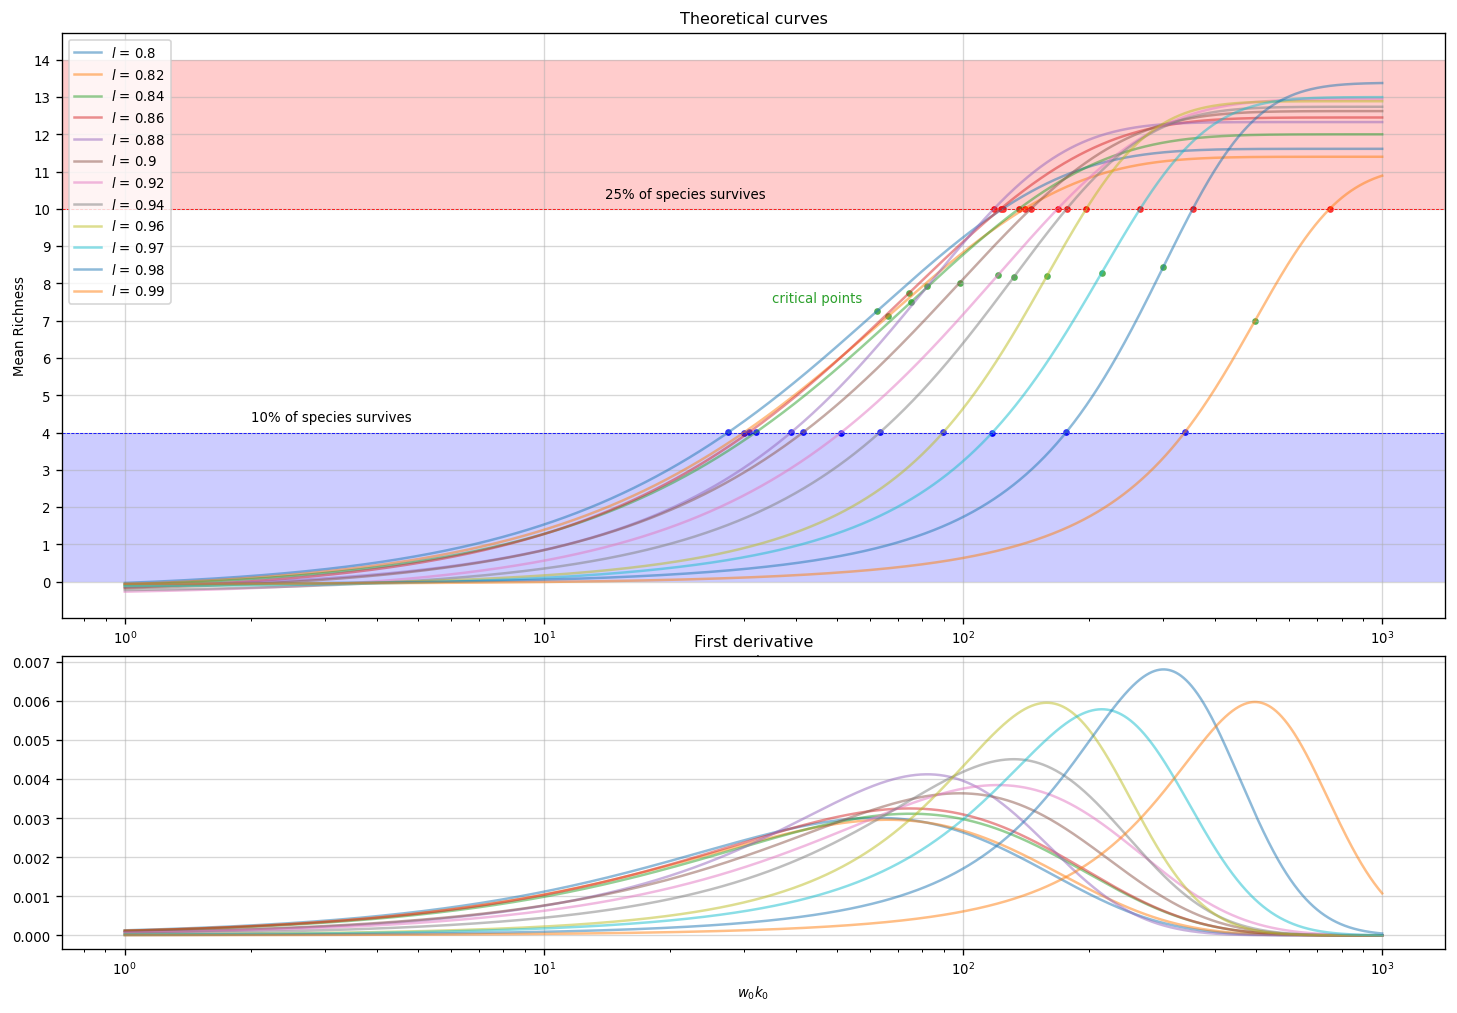

In [22]:
def ThrasholdPoint(curve, wk, popt, x):
    tp_x = wk[curve >= x][0]
    tp_y = sigmoid(tp_x,*popt)   
    return [tp_x,tp_y]

def CriticalPoint(curve, wk, popt):
    a = (np.diff(curve))
    cp_x = wk[1:][a == np.max(a)][0]
    cp_y = sigmoid(cp_x,*popt)   
    return [cp_x,cp_y]

low_perc = 10
low_threshold = (low_perc/100)*40

high_perc = 25
high_threshold = (high_perc/100)*40

curves = []
tps_DR = []
tps_RR = []
cps = []

fit_params = data["fit_params_80"], data["fit_params_82"], data["fit_params_84"], data["fit_params_86"], data["fit_params_88"], data["fit_params_90"], data["fit_params_92"], data["fit_params_94"], data["fit_params_96"], data["fit_params_97"], data["fit_params_98"], data["fit_params_99"]
names = [0.80,0.82,0.84,0.86,0.88,0.90,0.92,0.94,0.96,0.97,0.98,0.99]
wk = np.logspace(0, 3, num=int(1e4), base=10)

for i, params in enumerate(fit_params):
    curve = sigmoid(wk, *params)
    curve_der = np.diff(curve)

    tp_dr = ThrasholdPoint(curve, wk, params, x=high_threshold)
    tp_rr = ThrasholdPoint(curve, wk, params, x=low_threshold)
    cp = CriticalPoint(curve, wk, params) 

    curves.append(curve)
    tps_DR.append(tp_dr)   
    tps_RR.append(tp_rr)    
    cps.append(cp)

curves_derivative = np.diff(curves)

xlogscale=True

fig, ax = plt.subplots(2,1, figsize=(12,8), gridspec_kw={"height_ratios": [2, 1]})
fig.tight_layout(pad=0.5)

for i,j in zip(curves,names):
    ax[0].plot(wk,i,label="$l$ = "+str(j),alpha=0.5)
for tp in tps_DR:
    ax[0].scatter(tp[0],tp[1],marker=".",c="red")
for tp in tps_RR:
    ax[0].scatter(tp[0],tp[1],marker=".",c="blue")
for cp in cps:
    ax[0].scatter(cp[0],cp[1],marker=".",c="tab:green")

ax[0].axhline(y=high_threshold, ls="--",lw=0.5,c="red")
ax[0].text(14,high_threshold+0.3, "{}% of species survives".format(high_perc))
ax[0].axhspan(high_threshold, 14, facecolor='red', alpha=0.2)
#ax[0].text(1150,10.5, "Diverse Regime", rotation=90,fontsize=7)

ax[0].axhspan(low_threshold, high_threshold, facecolor='white', alpha=0.2)
ax[0].text(35,7.5, "critical points",color="tab:green",fontsize=8)
#ax[0].text(1150,5.7, "Linear Regime", rotation=90,fontsize=7)

ax[0].axhline(y=low_threshold, ls="--",lw=0.5,c="blue")
ax[0].text(2,low_threshold+0.3, "{}% of species survives".format(low_perc))
ax[0].axhspan(0, low_threshold, facecolor='blue', alpha=0.2)
#ax[0].text(1150,0.2, "Restricted Regime", rotation=90,fontsize=7)

ax[0].set_yticks(range(0,15))
ax[0].set(xlabel="$w_0k_0$",ylabel="Mean Richness",title="Theoretical curves")
ax[0].grid(alpha=0.5)
ax[0].legend(loc=2)

for i,j in zip(curves_derivative,names):
    ax[1].plot(wk[1:],i,label="$l$ = "+str(j),alpha=0.5)
ax[1].grid(alpha=0.5)

ax[1].set(xlabel="$w_0k_0$",ylabel="",title="First derivative")

if xlogscale:
    ax[0].set_xscale("log")
    ax[1].set_xscale("log");

After obtaining the theoretical curves representing the richness as a function of the external energy flux, our next step was to identify three characteristic values of $w_0k_0$ for each curve. These values include two threshold points, at which 10% and 25% of the species survive in the steady state, and a critical point, which marks the point where the slope of the curve is maximum.

By identifying these characteristic values, we were able to discern three distinct trends within the curves. The first trend corresponds to a non-linear region where the richness remains below 10% of the total species. This region roughly corresponds to the Restricted Regime, characterized by low richness and limited species survival.

The second trend corresponds to an approximately linear growth region, where the richness increases steadily up to 25%. This region indicates a transition zone where the community experiences an increase in richness.

Finally, the third trend corresponds to a non-linear growth region, which coincides with the Diverse Regime. In this region the richness exhibits a slow increase despite the high level of diversity and survival.

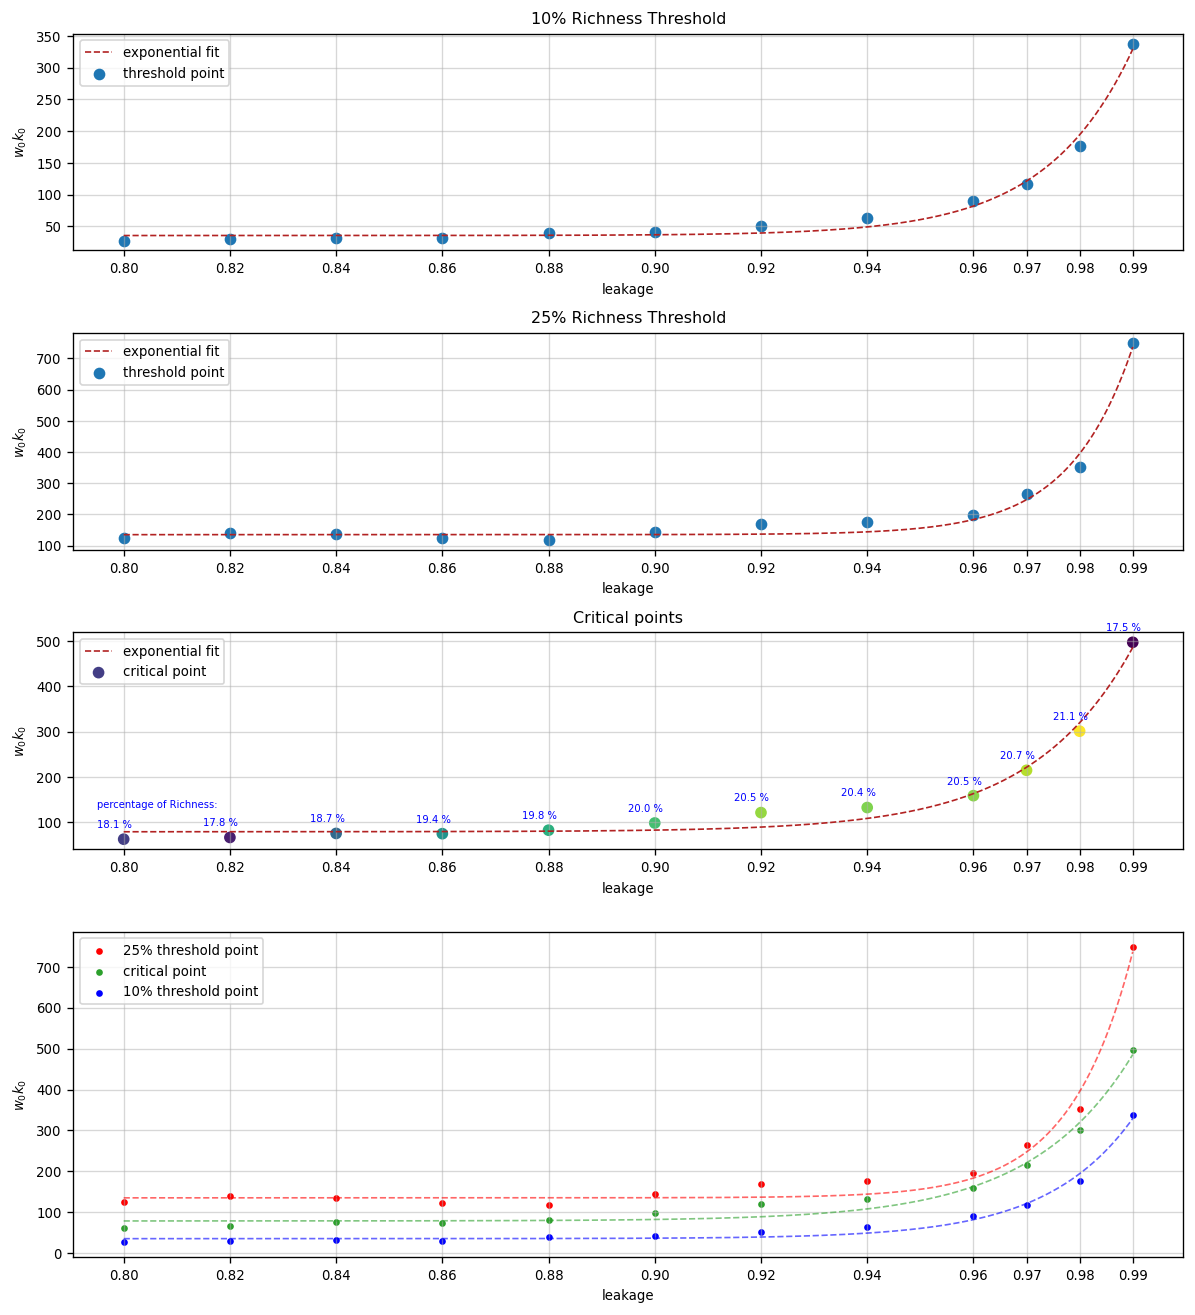

In [23]:
def exponential(x, A, B, a):
    y = A * np.exp(a * x ) + B
    return y

leakage=np.array(names)

tps_DR=np.array(tps_DR)
tp_wk_DR = tps_DR[:,0]

tps_RR=np.array(tps_RR)
tp_wk_RR = tps_RR[:,0]

cps=np.array(cps)
cp_wk = cps[:,0]

popt_tp_DR, pcov_tp_DR = curve_fit(exponential, leakage, tp_wk_DR, maxfev=int(1e6),method="trf")
popt_tp_RR, pcov_tp_RR = curve_fit(exponential, leakage, tp_wk_RR, maxfev=int(1e6),method="trf")
popt_cp, pcov_cp = curve_fit(exponential, leakage, cp_wk, maxfev=int(1e6),method="trf")

percentage=np.round((cps[:,1]/40)*100,1)
percentage=[str(i) for i in percentage]
symbol=["%"]*len(percentage)
percentage=[i+" "+j for i,j in zip(percentage,symbol)]

leakage_fine=np.linspace(0.8,0.99,int(1e4))


fig = plt.figure(tight_layout=True, figsize=(10,11))
gs = gridspec.GridSpec(4, 1, height_ratios=(1,1,1,1.5))

ax = fig.add_subplot(gs[0])
ax.set(title="{}% Richness Threshold".format(low_perc),xlabel="leakage",ylabel="$w_0k_0$")
ax.plot(leakage_fine,exponential(leakage_fine,*popt_tp_RR),color="firebrick",ls="--",lw=1,label="exponential fit")
ax.scatter(leakage,tp_wk_RR,label="threshold point",marker="o")
ax.set_xticks(names)
ax.grid(alpha=0.5)
ax.legend()

ax = fig.add_subplot(gs[1])
ax.set(title="{}% Richness Threshold".format(high_perc),xlabel="leakage",ylabel="$w_0k_0$")
ax.plot(leakage_fine,exponential(leakage_fine,*popt_tp_DR),color="firebrick",ls="--",lw=1,label="exponential fit")
ax.scatter(leakage,tp_wk_DR,label="threshold point",marker="o")
ax.set_xticks(names)
ax.grid(alpha=0.5)
ax.legend()

ax = fig.add_subplot(gs[2])
ax.set(xlabel="leakage",ylabel="$w_0k_0$",title="Critical points")
ax.plot(leakage_fine,exponential(leakage_fine,*popt_cp),color="firebrick",ls="--",lw=1,label="exponential fit")
ax.scatter(leakage,cp_wk,label="critical point",marker="o",c=cps[:,1])
ax.set_xticks(names)
ax.grid(alpha=0.5)
ax.legend()
ax.text(0.795,131, "percentage of Richness:", fontsize=6, c="blue")
for i in range(len(leakage)):
    ax.text(leakage[i]-0.005, cp_wk[i]+25, percentage[i], fontsize=6, c="blue")

ax = fig.add_subplot(gs[3])
ax.set(xlabel="leakage",ylabel="$w_0k_0$")
ax.plot(leakage_fine,exponential(leakage_fine,*popt_tp_DR),color="red",ls="--",lw=1,alpha=0.6)
ax.scatter(leakage,tps_DR[:,0],label="25% threshold point",marker=".",color="red")
ax.plot(leakage_fine,exponential(leakage_fine,*popt_cp),color="tab:green",ls="--",lw=1,alpha=0.6)
ax.scatter(leakage,cps[:,0],label="critical point",marker=".",color="tab:green")
ax.plot(leakage_fine,exponential(leakage_fine,*popt_tp_RR),color="blue",ls="--",lw=1,alpha=0.6)
ax.scatter(leakage,tps_RR[:,0],label="10% threshold point",marker=".",color="blue")
ax.set_xticks(names)
ax.grid(alpha=0.5)
ax.legend();

Once these characteristic values have been obtained, we can further investigate the relationship between leakage, $w_0k_0$, and richness. Regarding the threshold points, we observe that to achieve the desired percentage of richness, as the leakage increases, the energy flow must grow exponentially. This implies, as expected, that a higher leakage value requires a greater external energy input to sustain a specific level of richness.

Similarly, the critical points, which correspond to specific richness values and indicate the maximum slope of the curves, exhibit a similar trend. The richness associated with the critical point increases as the leakage increases up to a value of 0.98. However, beyond a leakage value of 0.98, the richness abruptly decreases. This behavior can be attributed to the fact that for a leakage value equal to 1, all absorbed energy by cells is reintroduced into the environment. Consequently, as the leakage approaches 1, the richness tends to decrease towards 0. These observations suggest that there exists an optimal leakage value around 0.98, which enables the community to achieve the maximum richness when accompanied by a sufficiently high external energy flux.

/var/folders/0d/wr4vslms6rx70gkgwp1_dz400000gn/T/ipykernel_96888/2685471451.py:6: RuntimeWarning: divide by zero encountered in power
  return(A*pow(x,B)+C)


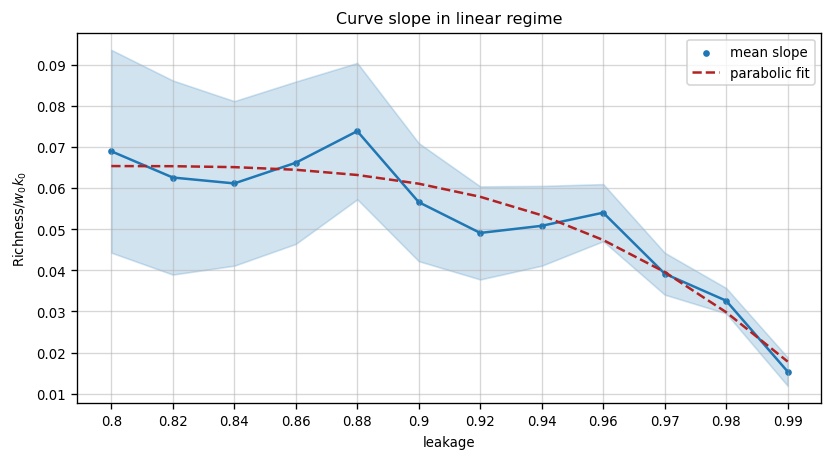

In [24]:
slopes_rr_cps=(cps[:,1]-tps_RR[:,1])/(cps[:,0]-tps_RR[:,0])
slopes_cps_dr=(tps_DR[:,1]-cps[:,1])/(tps_DR[:,0]-cps[:,0])
mean_slope=np.array([(i+j)/2 for i,j in zip(slopes_rr_cps,slopes_cps_dr)])

def f(x,A,B,C):
    return(A*pow(x,B)+C)

xx=np.arange(0,12)
popt, pcov = curve_fit(f, xx, mean_slope, maxfev=int(1e6),method="trf")


plt.figure(figsize=(8,4))
plt.title("Curve slope in linear regime")
plt.plot(mean_slope)
plt.scatter(xx,mean_slope,marker=".",label="mean slope")
plt.plot(xx,f(xx,*popt),color="firebrick",ls="--",label="parabolic fit")
plt.fill_between(xx,slopes_cps_dr,slopes_rr_cps,alpha=0.2,color="tab:blue")
plt.grid(alpha=0.5)
plt.legend()
plt.xticks(range(len(names)),names)
plt.xlabel("leakage")
plt.ylabel("Richness/$w_0k_0$");

The graph presented above displays the trend of the slope of the richness curves within the linear region, represented by the blue curve. The calculation of these values involved determining the slope between the 10% threshold value and the critical point, and between the critical point and the 25% threshold value. Subsequently, the average of these two slope values was computed.

Upon careful observation, it is evident that the mean slope in the linear area (i.e. the ratio between richness and $w_0k_0$) decreases in a power law manner as the leakage approaches a value of 1. This result is consistent with the previuous observations.

<a id="6"></a>
<a href ="#main"><p style="text-align: right;">return to contents</p></a>
## 6. Conclusions and future works

The implementation of the $\texttt{CommunityModelClass.py}$ has proven to be a highly effective tool for simulating bacterial communities with external resources, cross-feeding interactions, and stochastic colonization. Its straightforward structure and user-friendly interface allow for easy customization, enabling the characterization of specific communities. 

Our simulations have successfully validated several results presented in the article by Marsland III et al., particularly regarding the identification of two dynamic regimes based on richness, diversity, Niche Overlap, leakage, and external energy flow. Additionally, we extended the characterization of these regimes by estimating characteristic stability times, providing further insights into the temporal dynamics of species and resources within microbial communities.

Furthermore, our investigations have shed light on how richness varies in the presence of multiple external resources. We observed a non-linear increase in richness for intermediate values of $w_{\alpha}k_{\alpha}$ as the leakage parameter and the number of external resources increase. This finding suggests that the interplay between leakage, external energy input, and resource availability plays a crucial role in shaping the richness dynamics of microbial communities.

In exploring the dynamics under high leakage conditions with a single resource, we discovered an exponential relationship between leakage and external energy flux for maintaining a given richness value. Moreover, we observed that the slope in the linear region of the richness curve decreases following a power law as the leakage value approaches 1. These observations further elucidate the intricate relationship between leakage, external energy flow, and the rate of richness growth.

Moving forward, future investigations could explore the dynamics of the system in the presence of periodic external resources, simulating their seasonality and its impact on community dynamics. Additionally, with ample computational resources, it would be intriguing to simulate larger bacterial communities and observe any emergent behaviors that may arise in the thermodynamic limit.

-------------

## Bibliography

[1] MacArthur, Robert. "Species packing and competitive equilibrium for many species." Theoretical population biology 1.1 (1970): 1-11.

[2] Marsland III, Robert, et al. "Available energy fluxes drive a transition in the diversity, stability, and functional structure of microbial communities." PLoS computational biology 15.2 (2019): e1006793